# Liquid Neural Network (LNN) for FAS Spectral Extrapolation

### Problem Statement

Given observed Fourier Amplitude Spectra (FAS) at **f ≤ 1 Hz** (41 frequency bins, where physics-based simulations are reliable), predict FAS at **f > 1 Hz** .

### Two Parallel Models

| Model | Wave Type | Training Data |
|:---|:---|:---|
| **Horizontal** | S-waves (shear) | EW + NS combined |
| **Vertical** | P-waves (compressional) | UD only |




## 1. Imports & Global Configuration

In [ ]:
import warnings, random, os, math, re
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.ndimage import uniform_filter1d

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
import pickle

# ── Reproducibility ────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── Global plot style ──────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120, 'font.size': 11,
    'axes.grid': True, 'grid.alpha': 0.3,
    'axes.spines.top': False, 'axes.spines.right': False,
    'legend.framealpha': 0.85,
})

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch  : {torch.__version__}")
print(f"Device   : {DEVICE}")
print(f"NumPy    : {np.__version__}")
print(f"Pandas   : {pd.__version__}")
print(f"Seed     : {SEED}")


PyTorch  : 2.10.0
Device   : cpu
NumPy    : 2.1.3
Pandas   : 2.3.3
Seed     : 42


## 2. Data Loading

### Structure

The Excel workbook has **three sheets** — EW, NS, UD — each with:
- **6 metadata columns**: `Equid` (event ID), `Repi` (epicentral distance, km), `Vs30` (site velocity, m/s), `Depth` (focal depth, km), `FM` (fault mechanism code: 1=Strike-Slip, 2=Normal, 3=Reverse, 4=Undefined), `Magnitude` (Mw)
- **Frequency columns**: log-spaced from 0.01 Hz upward

#### Key Pre-processing Step: Remove f = 25 Hz

The column labelled `25` (i.e., 25 Hz) falls outside the reliable simulation range and is **explicitly removed** before any processing.

### LF / HF Boundary at 1 Hz

The **1 Hz split** separates:
- **Input (LF)**: 41 frequency bins from 0.01 – 1.0 Hz → fed as a sequence to the LNN
- **Target (HF)**: 27 frequency bins from > 1.0 Hz → predicted by the LNN


In [ ]:
FAS_FILE   = 'Final_data_FAS.xlsx'
META_COLS  = ['Equid', 'Repi', 'Vs30', 'Depth', 'FM', 'Magnitude']
SPLIT_FREQ = 1.0   # Hz

def load_sheet(filepath, sheet_name):
    """
    Load one FAS sheet.
    - Removes all META_COLS from frequency parsing
    - Explicitly removes the f = 25 Hz column (str(c) != '25')
    Returns: df, freqs (array), freq_cols (list of column names)
    """
    df = pd.read_excel(filepath, sheet_name=sheet_name)
    freq_cols = [c for c in df.columns
                 if c not in META_COLS and str(c) != '25']
    freqs = np.array([float(c) for c in freq_cols])
    return df, freqs, freq_cols


df_ew, freqs, freq_cols = load_sheet(FAS_FILE, 'EW')
df_ns, _,     _         = load_sheet(FAS_FILE, 'NS')
df_ud, _,     _         = load_sheet(FAS_FILE, 'UD')

input_mask   = freqs <= SPLIT_FREQ
output_mask  = freqs >  SPLIT_FREQ
input_freqs  = freqs[input_mask]
output_freqs = freqs[output_mask]
input_cols   = [c for c, m in zip(freq_cols, input_mask)  if m]
output_cols  = [c for c, m in zip(freq_cols, output_mask) if m]

N_STEPS   = len(input_cols)
N_OUTPUTS = len(output_cols)

print(f"Total frequency columns (after removing f=25 Hz): {len(freqs)}")
print(f"LF input  (f <= 1 Hz) : {N_STEPS:3d} bins  [{input_freqs[0]:.4f} – {input_freqs[-1]:.4f} Hz]")
print(f"HF target (f >  1 Hz) : {N_OUTPUTS:3d} bins  [{output_freqs[0]:.4f} – {output_freqs[-1]:.4f} Hz]")
print(f"Records per component  : {len(df_ew)} (EW), {len(df_ns)} (NS), {len(df_ud)} (UD)")
print(f"Unique events          : {df_ew['Equid'].nunique()}")
df_ew.head(3)


Total frequency columns (after removing f=25 Hz): 68
LF input  (f <= 1 Hz) :  41 bins  [0.0100 – 1.0000 Hz]
HF target (f >  1 Hz) :  27 bins  [1.1220 – 22.3872 Hz]
Records per component  : 925 (EW), 925 (NS), 925 (UD)
Unique events          : 173


,Equid,Repi,Vs30,Depth,Magnitude,FM,0.01,0.01122,0.012589,0.014125,...,8.912509,10.0,11.220185,12.589254,14.125375,15.848932,17.782794,19.952623,22.387211,25
0,1,77.74,270,47.0,5.3,4,0.000027,0.000028,0.000028,0.000029,...,0.000592,0.000335,0.000479,0.000292,0.000349,0.000277,0.000321,0.000155,0.000063,0.000004
1,1,20.56,270,47.0,5.3,4,0.000058,0.000059,0.000061,0.000062,...,0.001271,0.000644,0.000794,0.000247,0.000217,0.000192,0.000213,0.000070,0.000100,0.000007
2,1,20.47,1130,47.0,5.3,4,0.000019,0.000019,0.000020,0.000020,...,0.000423,0.000342,0.000384,0.000070,0.000054,0.000075,0.000064,0.000110,0.000029,0.000002


## 3. Exploratory Data Analysis

### 3.1 Metadata Statistics

In [ ]:
print("=" * 55)
print("   EW Component — Metadata Statistics")
print("=" * 55)
print(df_ew[['Repi', 'Vs30', 'Depth', 'FM', 'Magnitude']].describe().round(3))

fm_map = {1: 'Strike-Slip', 2: 'Normal', 3: 'Reverse', 4: 'Undefined'}
print(f"\nFM mapping : 1=Strike-Slip  2=Normal  3=Reverse  4=Undefined")
for k, v in df_ew['FM'].value_counts().sort_index().items():
    print(f"  FM={k} ({fm_map[k]:>12s}) : {v} records  ({100*v/len(df_ew):.1f}%)")

print(f"\nVs30 values : {sorted(df_ew['Vs30'].unique())} m/s")
print(f"Magnitude range : {df_ew['Magnitude'].min():.1f} – {df_ew['Magnitude'].max():.1f} Mw")
print(f"Repi range      : {df_ew['Repi'].min():.1f} – {df_ew['Repi'].max():.1f} km")
print(f"Depth range     : {df_ew['Depth'].min():.1f} – {df_ew['Depth'].max():.1f} km")


   EW Component — Metadata Statistics
           Repi      Vs30    Depth       FM  Magnitude
count   925.000   925.000  925.000  925.000    925.000
mean    206.210   631.557   28.756    2.241      5.404
std     255.167   393.710   32.917    0.550      1.138
min       0.050   270.000    5.000    1.000      3.000
25%      47.370   270.000   10.000    2.000      4.600
50%     113.090   560.000   15.000    2.000      5.500
75%     268.580  1130.000   33.000    2.000      6.300
max    4092.071  1130.000  188.000    4.000      7.800

FM mapping : 1=Strike-Slip  2=Normal  3=Reverse  4=Undefined
  FM=1 ( Strike-Slip) : 4 records  (0.4%)
  FM=2 (      Normal) : 745 records  (80.5%)
  FM=3 (     Reverse) : 125 records  (13.5%)
  FM=4 (   Undefined) : 51 records  (5.5%)

Vs30 values : [np.int64(270), np.int64(560), np.int64(1130)] m/s
Magnitude range : 3.0 – 7.8 Mw
Repi range      : 0.1 – 4092.1 km
Depth range     : 5.0 – 188.0 km


### 3.2 Dataset Statistics Plots

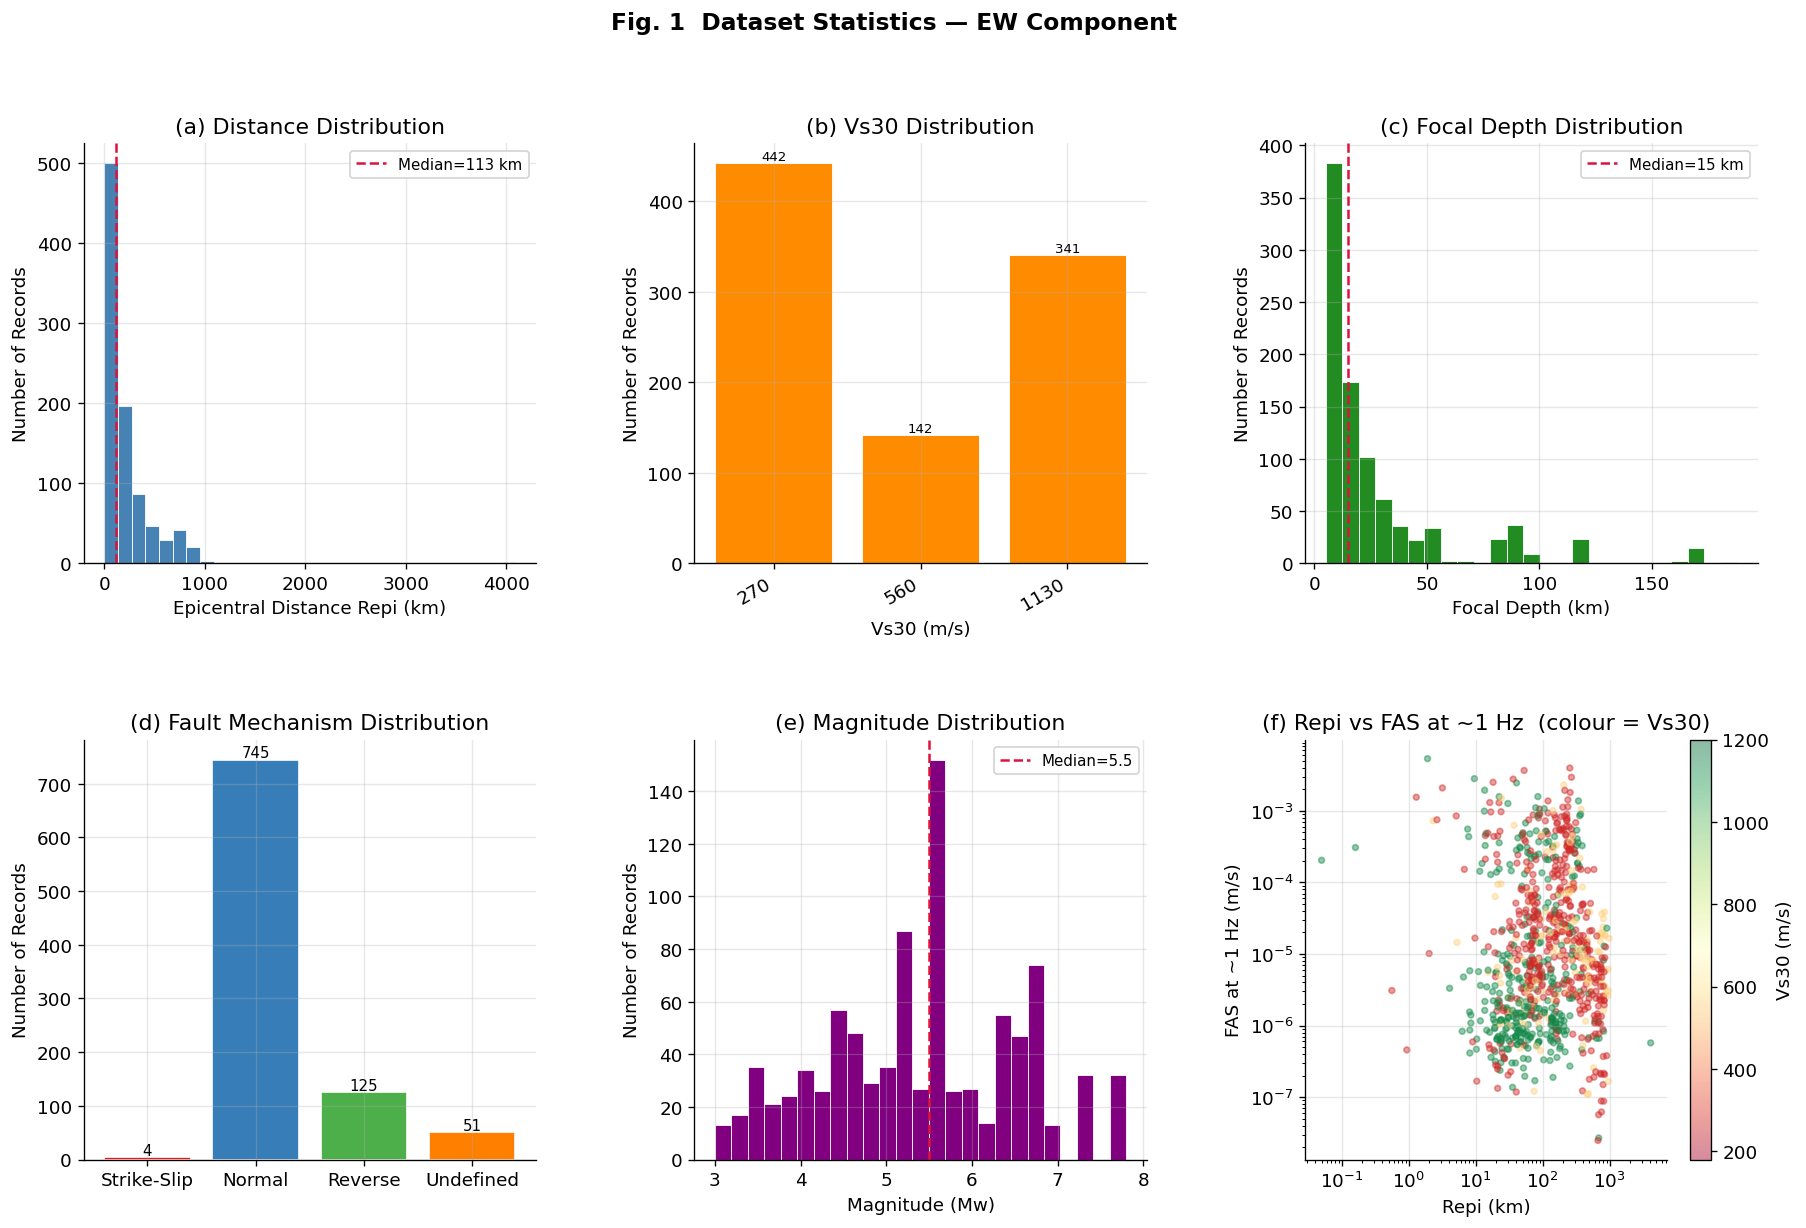

In [ ]:
col_1hz = input_cols[-1]   # column closest to 1 Hz

fig = plt.figure(figsize=(18, 11))
fig.suptitle('Fig. 1  Dataset Statistics — EW Component', fontsize=14, fontweight='bold')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)

# (a) Distance distribution
ax = fig.add_subplot(gs[0, 0])
ax.hist(df_ew['Repi'], bins=30, color='steelblue', edgecolor='white', linewidth=0.5)
ax.set_xlabel('Epicentral Distance Repi (km)')
ax.set_ylabel('Number of Records')
ax.set_title('(a) Distance Distribution')
ax.axvline(df_ew['Repi'].median(), color='crimson', ls='--', lw=1.5,
           label=f"Median={df_ew['Repi'].median():.0f} km")
ax.legend(fontsize=9)

# (b) Vs30 distribution
ax = fig.add_subplot(gs[0, 1])
vs30_counts = df_ew['Vs30'].value_counts().sort_index()
bars = ax.bar(vs30_counts.index.astype(str), vs30_counts.values,
              color='darkorange', edgecolor='white', linewidth=0.5)
for bar, v in zip(bars, vs30_counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+3,
            str(v), ha='center', fontsize=8)
ax.set_xlabel('Vs30 (m/s)')
ax.set_ylabel('Number of Records')
ax.set_title('(b) Vs30 Distribution')
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

# (c) Focal depth
ax = fig.add_subplot(gs[0, 2])
ax.hist(df_ew['Depth'], bins=25, color='forestgreen', edgecolor='white', linewidth=0.5)
ax.set_xlabel('Focal Depth (km)')
ax.set_ylabel('Number of Records')
ax.set_title('(c) Focal Depth Distribution')
ax.axvline(df_ew['Depth'].median(), color='crimson', ls='--', lw=1.5,
           label=f"Median={df_ew['Depth'].median():.0f} km")
ax.legend(fontsize=9)

# (d) Fault mechanism
ax = fig.add_subplot(gs[1, 0])
fm_cnts = df_ew['FM'].value_counts().sort_index()
fm_lbls = [fm_map[k] for k in fm_cnts.index]
fm_cols = ['#e41a1c', '#377eb8', '#4daf4a', '#ff7f00']
bars = ax.bar(fm_lbls, fm_cnts.values, color=fm_cols[:len(fm_cnts)], edgecolor='white')
for bar, v in zip(bars, fm_cnts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+4,
            str(v), ha='center', fontsize=9)
ax.set_ylabel('Number of Records')
ax.set_title('(d) Fault Mechanism Distribution')

# (e) Magnitude
ax = fig.add_subplot(gs[1, 1])
ax.hist(df_ew['Magnitude'], bins=25, color='purple', edgecolor='white', linewidth=0.5)
ax.set_xlabel('Magnitude (Mw)')
ax.set_ylabel('Number of Records')
ax.set_title('(e) Magnitude Distribution')
ax.axvline(df_ew['Magnitude'].median(), color='crimson', ls='--', lw=1.5,
           label=f"Median={df_ew['Magnitude'].median():.1f}")
ax.legend(fontsize=9)

# (f) Repi vs FAS at ~1 Hz coloured by Vs30
ax = fig.add_subplot(gs[1, 2])
sc = ax.scatter(df_ew['Repi'], df_ew[col_1hz], c=df_ew['Vs30'],
                cmap='RdYlGn', alpha=0.45, s=12,
                norm=plt.Normalize(180, 1200))
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Repi (km)')
ax.set_ylabel('FAS at ~1 Hz (m/s)')
ax.set_title('(f) Repi vs FAS at ~1 Hz  (colour = Vs30)')
plt.colorbar(sc, ax=ax, label='Vs30 (m/s)')

plt.tight_layout()
plt.show()


### 3.3 FAS Distribution at ~1 Hz — All Components

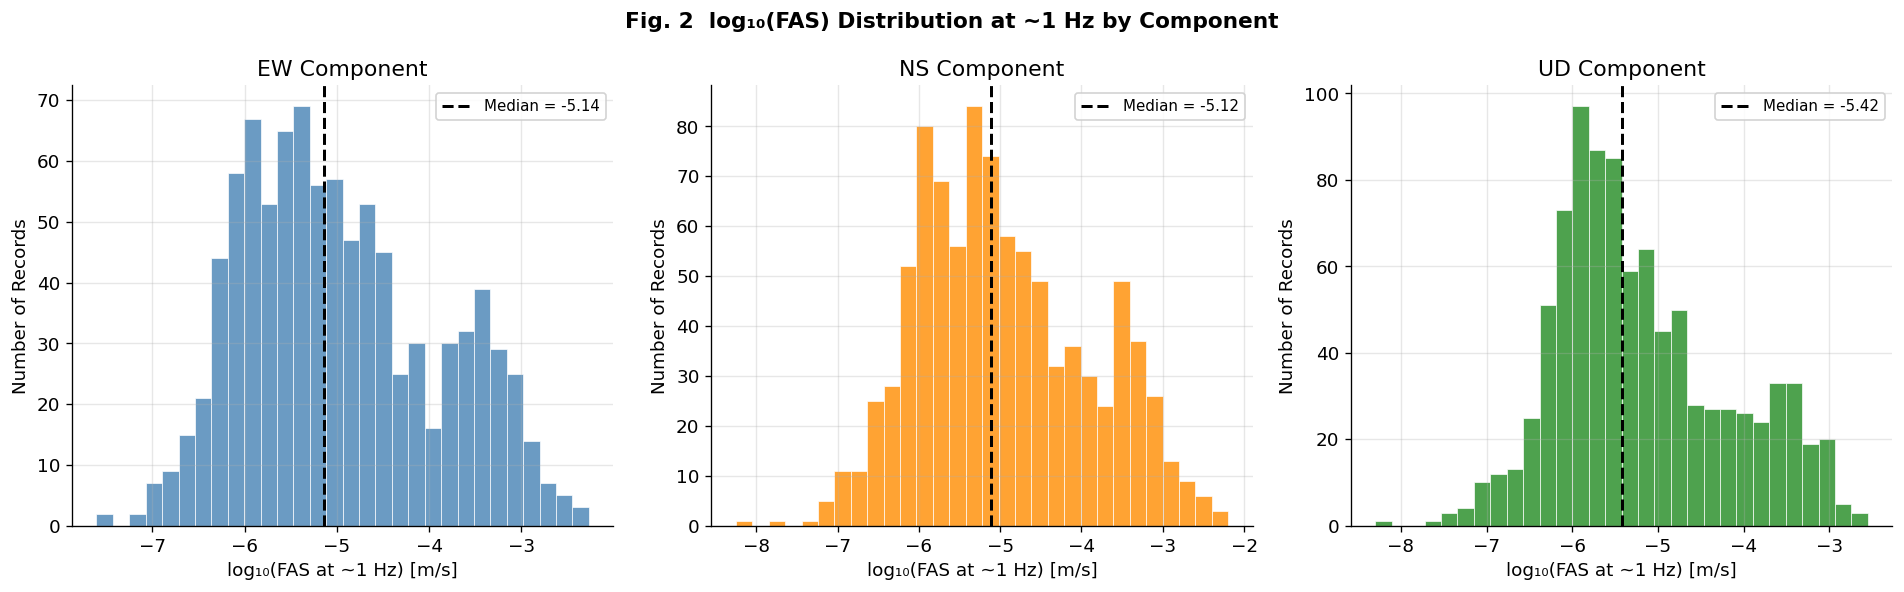

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Fig. 2  log₁₀(FAS) Distribution at ~1 Hz by Component',
             fontsize=13, fontweight='bold')

comp_cols = ['steelblue', 'darkorange', 'forestgreen']
for ax, df, label, col in zip(axes,
    [df_ew, df_ns, df_ud], ['EW', 'NS', 'UD'], comp_cols):
    vals = np.log10(np.clip(df[col_1hz].values, 1e-30, None))
    ax.hist(vals, bins=30, alpha=0.80, color=col, edgecolor='white', linewidth=0.5)
    med = np.median(vals)
    ax.axvline(med, color='k', ls='--', lw=1.8, label=f'Median = {med:.2f}')
    ax.set_xlabel('log₁₀(FAS at ~1 Hz) [m/s]')
    ax.set_ylabel('Number of Records')
    ax.set_title(f'{label} Component')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


### 3.4 Sample FAS Spectra — 50 Random Records per Component

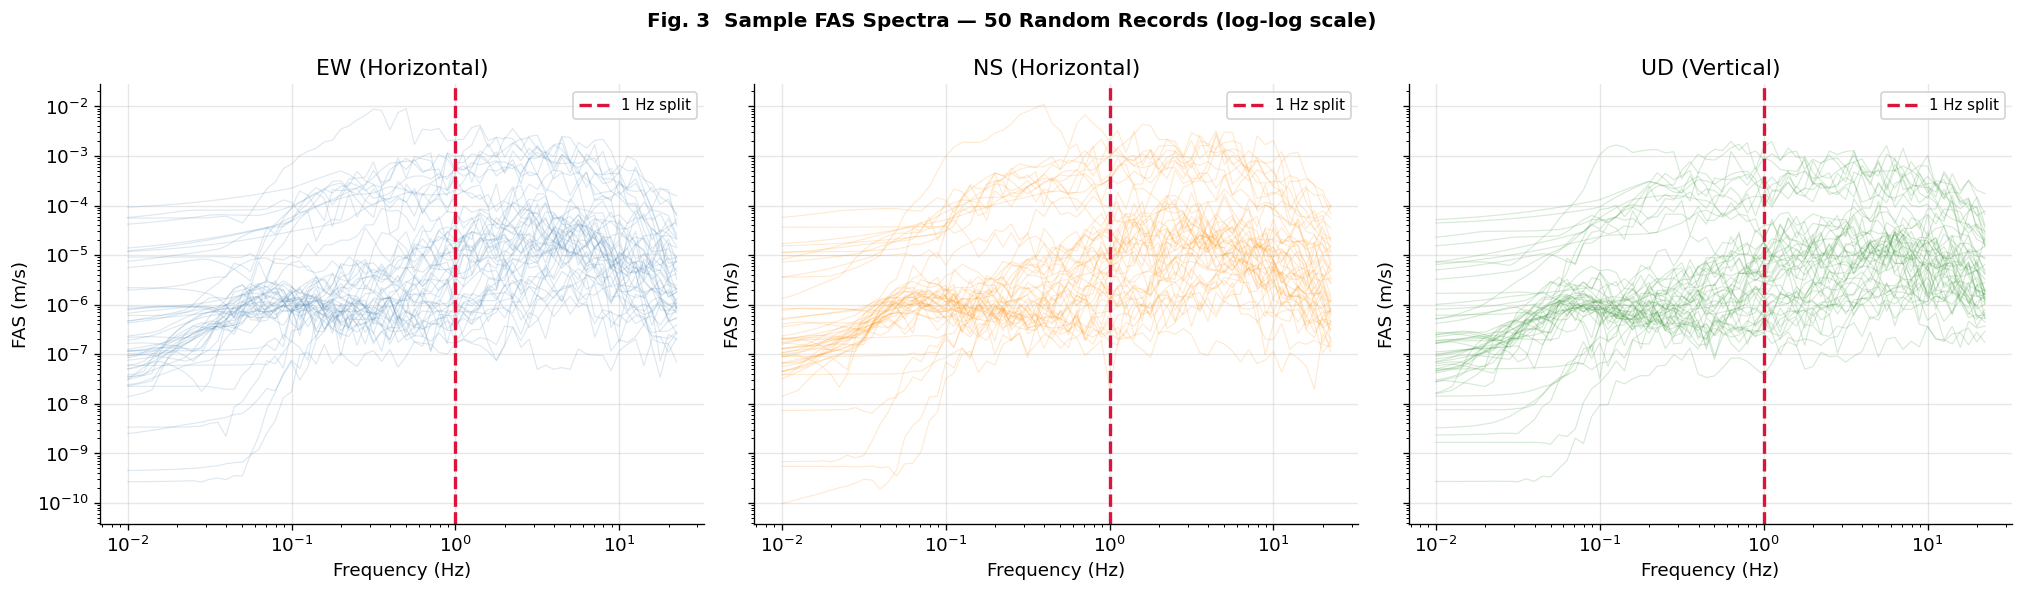

In [ ]:
np.random.seed(0)
idx_plot = np.random.choice(len(df_ew), 50, replace=False)

fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)
fig.suptitle('Fig. 3  Sample FAS Spectra — 50 Random Records (log-log scale)',
             fontsize=12, fontweight='bold')

for ax, df, title, col in zip(axes,
    [df_ew, df_ns, df_ud],
    ['EW (Horizontal)', 'NS (Horizontal)', 'UD (Vertical)'],
    ['steelblue', 'darkorange', 'forestgreen']):
    for i in idx_plot:
        ax.loglog(freqs, df[freq_cols].iloc[i].values,
                  color=col, alpha=0.18, lw=0.7)
    ax.axvline(1.0, color='crimson', ls='--', lw=2.0, label='1 Hz split')
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('FAS (m/s)')
    ax.set_title(title)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


### 3.5 Single Record — All Three Components Overlaid

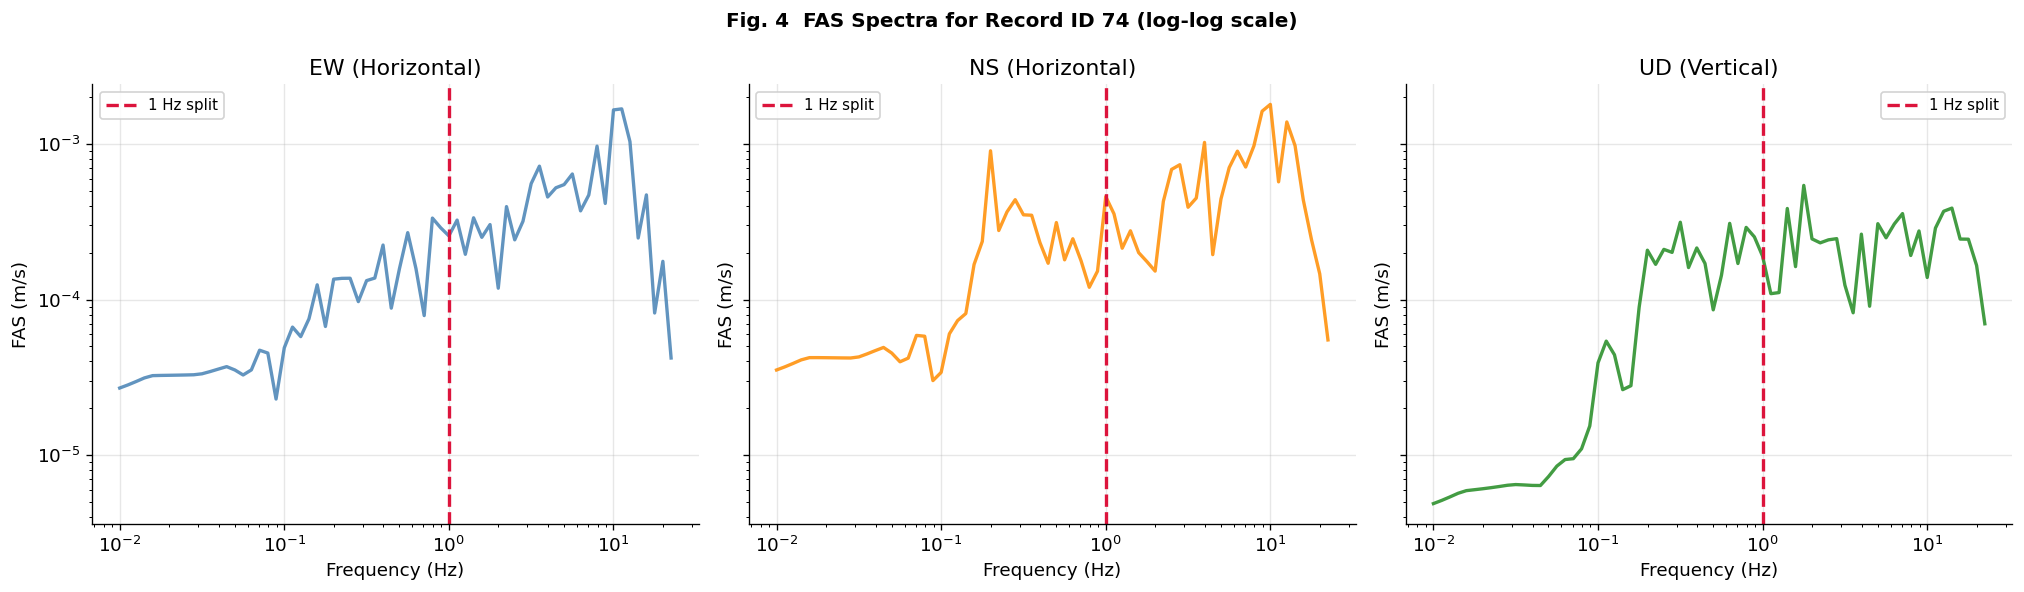

In [ ]:
record_id = 74
# 3 components for the same record, zoomed in
fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)
fig.suptitle(f"Fig. 4  FAS Spectra for Record ID {record_id} (log-log scale)",
             fontsize=12, fontweight='bold')
for ax, df, title, col in zip(axes,
    [df_ew, df_ns, df_ud],
    ['EW (Horizontal)', 'NS (Horizontal)', 'UD (Vertical)'],
    ['steelblue', 'darkorange', 'forestgreen']):
    ax.loglog(freqs, df[freq_cols].iloc[record_id].values,
              color=col, alpha=0.85, lw=2.0)
    ax.axvline(1.0, color='crimson', ls='--', lw=2.0, label='1 Hz split')
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('FAS (m/s)')
    ax.set_title(title)
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### 3.6 Magnitude–Distance Distribution (Mw–Repi Scatter)

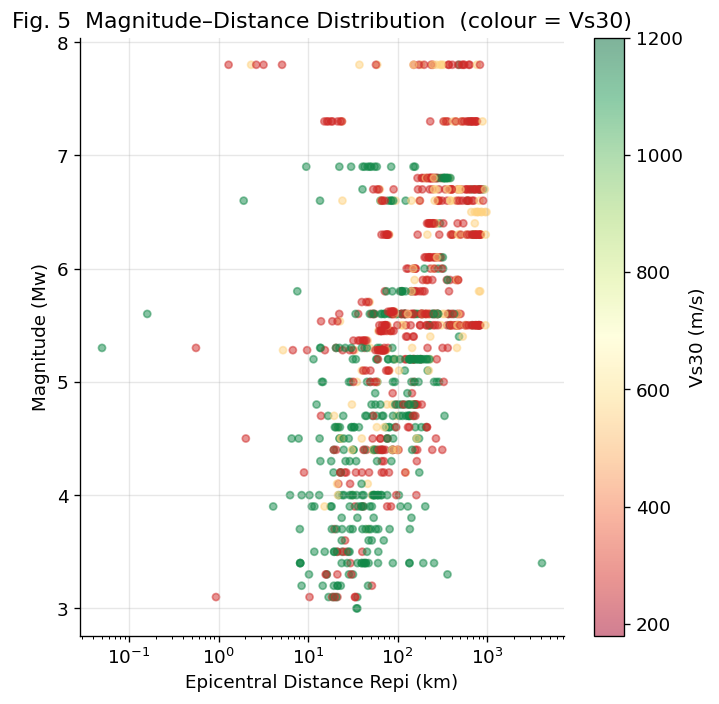

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
sc = ax.scatter(df_ew['Repi'], df_ew['Magnitude'],
                c=df_ew['Vs30'], cmap='RdYlGn', alpha=0.5, s=18,
                norm=plt.Normalize(180, 1200))
ax.set_xscale('log')
ax.set_xlabel('Epicentral Distance Repi (km)')
ax.set_ylabel('Magnitude (Mw)')
ax.set_title('Fig. 5  Magnitude–Distance Distribution  (colour = Vs30)')
plt.colorbar(sc, ax=ax, label='Vs30 (m/s)')
plt.tight_layout()
plt.show()


## 4. Feature Engineering — Metadata + LF FAS

### 4.1 Design Rationale

A systematic feature comparison study evaluated five input combinations on the same LNN architecture:

| Combination | Features/step | Validation R² | Notes |
|:---|:---:|:---:|:---|
| Metadata only | 7 | Lowest | No spectral shape information |
| LF FAS only | 1 | Moderate | No source/path/site context |
| **Metadata + LF FAS** | **8** | **Best trade-off** | ✅ Chosen configuration |
| Metadata + LF + derived + physics | 17 | Marginal gain | Overfitting risk, 2× compute |

The chosen configuration uses **8 features per time step**:

### 4.2 Feature Table

| Index | Feature | Formula | Physical Meaning |
|:---:|:---|:---|:---|
| 0 | **log₁₀(FAS(fₜ))** | log₁₀(A(fₜ)) | Primary spectral amplitude at LF step t (core ODE input) |
| 1 | log₁₀(Repi) | log₁₀(R) | Log epicentral distance — controls geometric spreading |
| 2 | log₁₀(Depth) | log₁₀(d) | Log focal depth — controls near-source path |
| 3 | FM_strike_slip | 𝟙[FM=1] | One-hot encoding: Strike-Slip mechanism |
| 4 | FM_reverse | 𝟙[FM=3] | One-hot encoding: Reverse mechanism |
| 5 | FM_normal | 𝟙[FM∈{2,4}] | One-hot encoding: Normal / Undefined |
| 6 | 1/Repi | 1/R | Geometric spreading proxy (body wave amplitude ∝ 1/R) |
| 7 | Magnitude | Mw | Moment magnitude — source size descriptor |



In [ ]:
def engineer_meta_lf(df, input_cols, input_freqs):
    """
    Build (N, T=41, 8) feature tensor:
      Feature 0 : log₁₀(FAS(fₜ)) — step-varying LF amplitude
      Features 1-7 : metadata broadcast to all T steps

    Parameters
    ----------
    df         : DataFrame with META_COLS + input_cols
    input_cols : list of T=41 frequency column names (LF)
    input_freqs: (T,) array of LF frequencies

    Returns
    -------
    X : (N, T, 8) float32 array
    """
    N, T = len(df), len(input_cols)
    fm   = df['FM'].values

    # ── Metadata features: (N, 7) ────────────────────────────────────────────
    meta = np.stack([
        np.log10(df['Repi'].values   + 1e-9),     # [1] log10(Repi)
        np.log10(df['Depth'].values  + 1e-9),     # [2] log10(Depth)
        (fm == 1).astype(float),                  # [3] Strike-Slip one-hot
        (fm == 3).astype(float),                  # [4] Reverse one-hot
        ((fm == 2) | (fm == 4)).astype(float),    # [5] Normal/Undef one-hot
        1.0 / (df['Repi'].values + 1e-9),         # [6] 1/Repi geometric spreading
        df['Magnitude'].values,                   # [7] Magnitude (Mw)
    ], axis=1).astype(np.float32)                 # (N, 7)

    # ── LF FAS: log10 transform → (N, T) ─────────────────────────────────────
    fas_raw = df[input_cols].values.astype(float)
    lf_log  = np.log10(np.clip(fas_raw, 1e-30, None)).astype(np.float32)  # (N, T)

    # ── Broadcast metadata: (N, 7) → (N, T, 7) ───────────────────────────────
    ctx = np.repeat(meta[:, np.newaxis, :], T, axis=1)   # (N, T, 7)

    # ── Concatenate: [log_fas(N,T,1), ctx(N,T,7)] → (N,T,8) ─────────────────
    X = np.concatenate([lf_log[:, :, np.newaxis], ctx], axis=2)
    return X.astype(np.float32)


def get_targets(df, output_cols):
    """Return log₁₀(FAS) for HF target frequencies. Shape: (N, N_OUTPUTS)."""
    fas = df[output_cols].values.astype(float)
    return np.log10(np.clip(fas, 1e-30, None)).astype(np.float32)


# ── Build feature arrays ─────────────────────────────────────────────────────
print('Building Metadata + LF FAS (8-feature) arrays...')
X_ew = engineer_meta_lf(df_ew, input_cols, input_freqs)
X_ns = engineer_meta_lf(df_ns, input_cols, input_freqs)
X_ud = engineer_meta_lf(df_ud, input_cols, input_freqs)

y_ew = get_targets(df_ew, output_cols)
y_ns = get_targets(df_ns, output_cols)
y_ud = get_targets(df_ud, output_cols)

X_H = np.concatenate([X_ew, X_ns], axis=0)   # Horizontal: EW + NS
y_H = np.concatenate([y_ew, y_ns], axis=0)
X_V = X_ud                                    # Vertical: UD only
y_V = y_ud

N_FEATURES = X_H.shape[2]   # = 8

print(f"  Horizontal  X: {X_H.shape}    y: {y_H.shape}")
print(f"  Vertical    X: {X_V.shape}    y: {y_V.shape}")
print(f"  Features/step : {N_FEATURES}  (1 log_FAS + 7 metadata)")
print(f"  LF steps      : {N_STEPS}")
print(f"  HF outputs    : {N_OUTPUTS}")


Building Metadata + LF FAS (8-feature) arrays...
  Horizontal  X: (1850, 41, 8)    y: (1850, 27)
  Vertical    X: (925, 41, 8)    y: (925, 27)
  Features/step : 8  (1 log_FAS + 7 metadata)
  LF steps      : 41
  HF outputs    : 27


## 5. Normalisation, Train/Val/Test Split & DataLoaders

### 5.1 Why Standardise?

The LTC ODE involves computing $f(h, x, \theta) = \tanh(W[h; x] + b)$. If features have wildly different scales, gradients will be dominated by large-scale features (e.g., 1/Repi ≈ 0.002 vs. Magnitude ≈ 6.0), causing slow or unstable training.

`StandardScaler` maps each feature to zero mean and unit variance:
$$\tilde{x}_d = \frac{x_d - \mu_d}{\sigma_d}$$

**Critical rule: fit the scaler on the training split ONLY**, then apply the same transform to validation and test splits. Fitting on all data would leak test-set statistics.

### 5.2 Split Rationale

| Split | Fraction | Purpose |
|:---|:---:|:---|
| **Train** | 70% | Model parameter learning |
| **Validation** | 15% | Hyperparameter selection, early stopping |
| **Test** | 15% | Final unbiased performance estimate |

A fixed random permutation (same seed) ensures all experiments use identical splits.


In [ ]:
class SeismicFASDataset(Dataset):
    """PyTorch Dataset wrapping (LF feature sequence, HF log-FAS targets)."""
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


def make_loaders(X, y, train_ratio=0.70, val_ratio=0.15,
                 batch_size=32, seed=SEED):
    """
    Split → scale (train-only fit) → wrap in DataLoaders.

    Returns
    -------
    loaders : dict of DataLoader  {'train', 'val', 'test'}
    scalers : dict of scaler      {'X': X_scaler, 'y': y_scaler}
    sizes   : dict of int         sample counts per split
    te_idx  : (n_test,) test-set indices into the original array
    """
    N = len(X)
    n_train = int(N * train_ratio)
    n_val   = int(N * val_ratio)

    rng    = np.random.default_rng(seed)
    perm   = rng.permutation(N)
    tr_idx = perm[:n_train]
    va_idx = perm[n_train:n_train + n_val]
    te_idx = perm[n_train + n_val:]

    n_steps, n_feat = X.shape[1], X.shape[2]
    X_2d = X.reshape(N, -1)   # (N, T*D) for StandardScaler

    X_sc = StandardScaler().fit(X_2d[tr_idx])
    y_sc = StandardScaler().fit(y[tr_idx])

    def scale_X(idx):
        return X_sc.transform(X_2d[idx]).reshape(-1, n_steps, n_feat)
    def scale_y(idx):
        return y_sc.transform(y[idx])

    ds = {
        'train': SeismicFASDataset(scale_X(tr_idx), scale_y(tr_idx)),
        'val':   SeismicFASDataset(scale_X(va_idx), scale_y(va_idx)),
        'test':  SeismicFASDataset(scale_X(te_idx), scale_y(te_idx)),
    }
    loaders = {k: DataLoader(v, batch_size=batch_size, shuffle=(k == 'train'))
               for k, v in ds.items()}
    scalers = {'X': X_sc, 'y': y_sc}
    sizes   = {k: len(v) for k, v in ds.items()}
    return loaders, scalers, sizes, te_idx


print('Horizontal loaders (EW + NS combined):')
ld_H, sc_H, sz_H, te_H = make_loaders(X_H, y_H)
total_H = sum(sz_H.values())
for split, n in sz_H.items():
    print(f"  {split:6s}: {n:5d} records ({100*n/total_H:.0f}%)")

print('\nVertical loaders (UD):')
ld_V, sc_V, sz_V, te_V = make_loaders(X_V, y_V)
total_V = sum(sz_V.values())
for split, n in sz_V.items():
    print(f"  {split:6s}: {n:5d} records ({100*n/total_V:.0f}%)")

# Keep raw test arrays for residual analysis and feature importance
X_H_test_raw = X_H[te_H]; y_H_test_raw = y_H[te_H]
X_V_test_raw = X_V[te_V]; y_V_test_raw = y_V[te_V]


Horizontal loaders (EW + NS combined):
  train :  1295 records (70%)
  val   :   277 records (15%)
  test  :   278 records (15%)

Vertical loaders (UD):
  train :   647 records (70%)
  val   :   138 records (15%)
  test  :   140 records (15%)


## 6. Liquid Time-Constant (LTC) Neural Network Architecture

### 6.1 The LTC ODE — Mathematical Foundation

A Liquid Time-Constant (LTC) neuron evolves its hidden state $h_i(t)$ according to the ODE:

$$\frac{dh_i}{dt} = -\left[\frac{1}{\tau_i} + f_i(h, x, \theta)\right] h_i + f_i(h, x, \theta) \cdot A_i$$

**Symbol glossary:**

| Symbol | Dimension | Role | Learned? |
|:---|:---:|:---|:---:|
| $h_i$ | scalar | Hidden state of neuron $i$ (spectral memory) | — (state variable) |
| $\tau_i > 0$ | scalar | **Time constant** — decay rate of neuron memory | ✓ |
| $A_i$ | scalar | **Equilibrium weight** — attractor of the ODE | ✓ |
| $f_i = \tanh(W[h; x] + b)$ | scalar | **Nonlinear gating** — modulates effective decay | ✓  |


### 6.2 Architecture: LNNEncoder + MLP Decoder

```
Input Sequence (batch, T=41, D=8)                Output (batch, N_OUTPUTS=27)
         │                                                 ↑
┌────────▼────────────────────────────┐   ┌────────────────┴──────────────┐
│  LNNEncoder (2 stacked LTC layers)  │   │  MLP Decoder                  │
│                                     │   │  Linear(H → 2H) + GELU        │
│  for t in 0 .. 40:                  │──►│  Dropout(p)                   │
│    h₁ = LTCCell(x_t, h₁)            │   │  Linear(2H → H) + GELU        │
│    h₂ = LTCCell(h₁, h₂)             │   │  Dropout(p)                   │
│  return h₂   [batch, H]             │   │  Linear(H → N_OUTPUTS)        │
└─────────────────────────────────────┘   └───────────────────────────────┘
```

The stacked design (2 LTC layers) allows the first layer to integrate the raw LF spectral sequence and the second layer to integrate the refined hidden representations, giving the encoder a richer vocabulary of spectral features.


In [ ]:
class LTCCell(nn.Module):
    """
    Single Liquid Time-Constant (LTC) neuron cell.

    ODE:  dh/dt = -[ 1/τ + f(h, x, θ) ] * h  +  f(h, x, θ) * A
    Solved via Euler integration with `ode_steps` sub-steps per call.

    Parameters
    ----------
    input_size  : int  — dimension of input vector x
    hidden_size : int  — number of LTC neurons H
    ode_steps   : int  — Euler sub-steps (default 6)
    """
    def __init__(self, input_size: int, hidden_size: int, ode_steps: int = 6):
        super().__init__()
        self.hidden_size = hidden_size
        self.ode_steps   = ode_steps

        # f(h, x, θ): nonlinear input-state gating function
        self.input_map = nn.Linear(input_size + hidden_size, hidden_size)

        # log(τ_i): ensures τ > 0 via exp(); initialised to 0 → τ=1
        self.log_tau = nn.Parameter(torch.zeros(hidden_size))

        # A_i: synaptic equilibrium weights; initialised to 1
        self.A = nn.Parameter(torch.ones(hidden_size))

        self.act = nn.Tanh()   # nonlinear activation σ

    def forward(self, x: torch.Tensor, h: torch.Tensor) -> torch.Tensor:
        """
        x : (batch, input_size)   — features at current frequency step
        h : (batch, hidden_size)  — current ODE hidden state
        Returns h_new : (batch, hidden_size)
        """
        tau = torch.exp(self.log_tau).unsqueeze(0)   # (1, H) → broadcast over batch
        dt  = 1.0 / self.ode_steps

        for _ in range(self.ode_steps):
            combined = torch.cat([x, h], dim=-1)           # (B, D+H)
            f        = self.act(self.input_map(combined))   # (B, H)   ← f(h,x,θ)
            # Euler: h ← h + dt * [ -(1/τ + f)*h + f*A ]
            dh = (-(1.0 / tau + f) * h + f * self.A) * dt
            h  = h + dh

        return h


class LNNEncoder(nn.Module):
    """
    Stack of n_layers LTC cells sweeping the T=41 LF frequency steps.
    The final hidden state encodes the entire LF spectral history.
    """
    def __init__(self, input_size: int, hidden_size: int,
                 n_layers: int = 2, ode_steps: int = 6):
        super().__init__()
        self.hidden_size = hidden_size
        self.n_layers    = n_layers
        self.cells = nn.ModuleList([
            LTCCell(input_size if i == 0 else hidden_size, hidden_size, ode_steps)
            for i in range(n_layers)
        ])

    def forward(self, x_seq: torch.Tensor) -> torch.Tensor:
        """x_seq: (batch, T=41, D=8)  →  h_final: (batch, H)"""
        B = x_seq.size(0)
        h = [torch.zeros(B, self.hidden_size, device=x_seq.device)
             for _ in range(self.n_layers)]

        for t in range(x_seq.size(1)):     # 41 LF frequency steps
            inp = x_seq[:, t, :]           # (B, D)
            for l, cell in enumerate(self.cells):
                h[l] = cell(inp, h[l])     # update ODE state
                inp  = h[l]                # feed into next layer

        return h[-1]   # final state = compressed spectral memory


class SeismicLNN(nn.Module):
    """
    Full LNN: LNNEncoder → MLP Decoder → log₁₀(FAS) at HF bins.
    """
    def __init__(self, input_size: int = 8, hidden_size: int = 64,
                 output_size: int = 27, n_layers: int = 2,
                 ode_steps: int = 6, dropout: float = 0.2):
        super().__init__()
        self.encoder = LNNEncoder(input_size, hidden_size, n_layers, ode_steps)
        self.decoder = nn.Sequential(
            nn.Linear(hidden_size, hidden_size * 2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden_size * 2, hidden_size), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden_size, output_size)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.decoder(self.encoder(x))


# ── Sanity check ──────────────────────────────────────────────────────────────
_m  = SeismicLNN(input_size=N_FEATURES, hidden_size=64, output_size=N_OUTPUTS)
_x  = torch.randn(4, N_STEPS, N_FEATURES)
_y  = _m(_x)
_np = sum(p.numel() for p in _m.parameters() if p.requires_grad)
print(f"Forward pass: ({4}, {N_STEPS}, {N_FEATURES}) → {tuple(_y.shape)}")
print(f"Trainable parameters (hidden=64, n_layers=2, ode_steps=6): {_np:,}")
del _m, _x, _y


Forward pass: (4, 41, 8) → (4, 27)
Trainable parameters (hidden=64, n_layers=2, ode_steps=6): 31,515


## 7. Hyperparameter Tuning

Three-phase sequential grid search using 50-epoch proxy training runs on the horizontal dataset.

**Search space:**
- **Hidden size** $H \in \{32, 64, 128\}$ — controls model capacity and the dimension of the LTC state
- **Learning rate** $\eta \in \{5\times10^{-4}, 10^{-3}, 2\times10^{-3}\}$ — Adam step size
- **Dropout rate** $p \in \{0.2, 0.3, 0.4\}$ — regularisation in the MLP decoder

Each configuration is evaluated by the **minimum validation MSE** achieved before early stopping.


In [ ]:
def quick_train(hidden_size, lr, dropout, loaders, sizes, n_epochs=50, patience=15):
    """Short proxy training for hyperparameter search. Returns (best_val_mse, n_params)."""
    model = SeismicLNN(N_FEATURES, hidden_size, N_OUTPUTS,
                       n_layers=2, ode_steps=6, dropout=dropout).to(DEVICE)
    opt   = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    crit  = nn.MSELoss()
    best_val, no_imp = float('inf'), 0

    for ep in range(n_epochs):
        model.train()
        for xb, yb in loaders['train']:
            opt.zero_grad()
            crit(model(xb.to(DEVICE)), yb.to(DEVICE)).backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
        model.eval()
        with torch.no_grad():
            va = sum(crit(model(xb.to(DEVICE)), yb.to(DEVICE)).item() * len(xb)
                     for xb, yb in loaders['val']) / sizes['val']
        if va < best_val:
            best_val = va; no_imp = 0
        else:
            no_imp += 1
            if no_imp >= patience: break

    n_par = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return best_val, n_par


# ── Phase 1: Hidden size ──────────────────────────────────────────────────────
print(f"{'Phase 1: Hidden Size':^55}")
print(f"{'Hidden':>8}  {'LR':>8}  {'Dropout':>8}  {'Val MSE':>10}  {'Params':>10}")
print('─' * 55)
hs_results = []
for hs in [32, 64, 128]:
    val_mse, n_par = quick_train(hs, 1e-3, 0.2, ld_H, sz_H)
    hs_results.append((hs, 1e-3, 0.2, val_mse, n_par))
    print(f"{hs:>8}  {1e-3:>8.4f}  {0.2:>8.2f}  {val_mse:>10.6f}  {n_par:>10,}")

best_hs = min(hs_results, key=lambda r: r[3])[0]
print(f"  → Best hidden size: {best_hs}")

# ── Phase 2: Learning rate ────────────────────────────────────────────────────
print(f"\n{'Phase 2: Learning Rate':^55}")
lr_results = []
for lr in [5e-4, 1e-3, 2e-3]:
    val_mse, _ = quick_train(best_hs, lr, 0.2, ld_H, sz_H)
    lr_results.append((lr, val_mse))
    print(f"  hidden={best_hs}  lr={lr:.0e}  dropout=0.20  val_mse={val_mse:.6f}")

best_lr = min(lr_results, key=lambda r: r[1])[0]
print(f"  → Best LR: {best_lr}")

# ── Phase 3: Dropout rate ─────────────────────────────────────────────────────
print(f"\n{'Phase 3: Dropout Rate':^55}")
dr_results = []
for dr in [0.2, 0.3, 0.4]:
    val_mse, _ = quick_train(best_hs, best_lr, dr, ld_H, sz_H)
    dr_results.append((dr, val_mse))
    print(f"  hidden={best_hs}  lr={best_lr:.0e}  dropout={dr:.2f}  val_mse={val_mse:.6f}")

BEST_HIDDEN  = best_hs
BEST_LR      = best_lr
BEST_DROPOUT = min(dr_results, key=lambda r: r[1])[0]
print(f"\n>>> Final hyperparameters:")
print(f"    hidden_size = {BEST_HIDDEN}")
print(f"    lr          = {BEST_LR}")
print(f"    dropout     = {BEST_DROPOUT}")


                 Phase 1: Hidden Size                  
  Hidden        LR   Dropout     Val MSE      Params
───────────────────────────────────────────────────────
      32    0.0010      0.20    0.161531       8,603
      64    0.0010      0.20    0.155041      31,515
     128    0.0010      0.20    0.145179     120,347
  → Best hidden size: 128

                Phase 2: Learning Rate                 
  hidden=128  lr=5e-04  dropout=0.20  val_mse=0.145347
  hidden=128  lr=1e-03  dropout=0.20  val_mse=0.147100
  hidden=128  lr=2e-03  dropout=0.20  val_mse=0.152555
  → Best LR: 0.0005

                 Phase 3: Dropout Rate                 
  hidden=128  lr=5e-04  dropout=0.20  val_mse=0.141064
  hidden=128  lr=5e-04  dropout=0.30  val_mse=0.150114
  hidden=128  lr=5e-04  dropout=0.40  val_mse=0.151858

>>> Final hyperparameters:
    hidden_size = 128
    lr          = 0.0005
    dropout     = 0.2


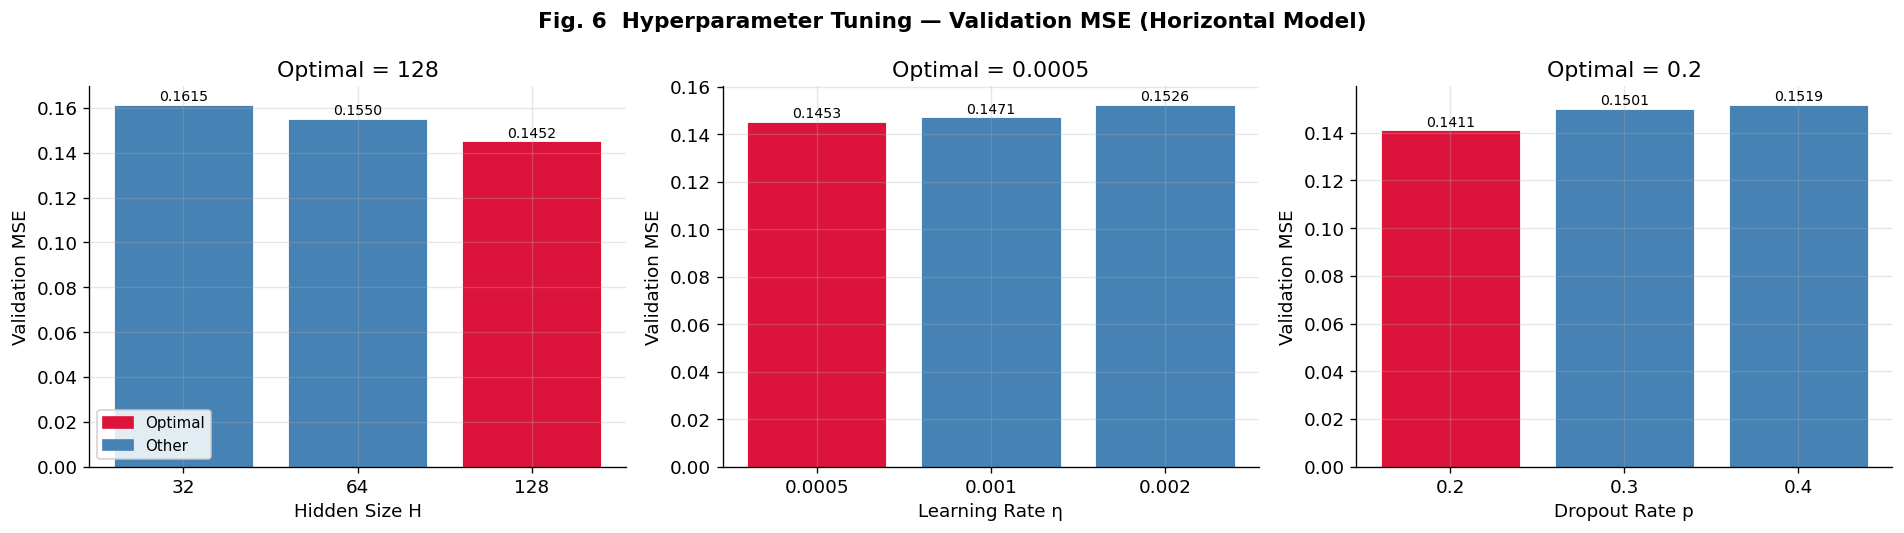

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
fig.suptitle('Fig. 6  Hyperparameter Tuning — Validation MSE (Horizontal Model)',
             fontsize=13, fontweight='bold')

for ax, data, xlabel, optimal, raw_data in zip(axes,
    [hs_results, lr_results, dr_results],
    ['Hidden Size H', 'Learning Rate η', 'Dropout Rate p'],
    [BEST_HIDDEN, BEST_LR, BEST_DROPOUT],
    [hs_results, lr_results, dr_results]):

    vals = [r[0] for r in data]
    mses = [r[3] if len(r) > 2 else r[1] for r in data]
    cols = ['crimson' if v == optimal else 'steelblue' for v in vals]
    bars = ax.bar([str(v) for v in vals], mses, color=cols, edgecolor='white', linewidth=0.5)
    for bar, mse in zip(bars, mses):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.012,
                f'{mse:.4f}', ha='center', fontsize=8.5)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Validation MSE')
    ax.set_title(f'Optimal = {optimal}')

handles = [mpatches.Patch(color='crimson', label='Optimal'),
           mpatches.Patch(color='steelblue', label='Other')]
axes[0].legend(handles=handles, fontsize=9)
plt.tight_layout()
plt.show()


## 8. Training

### Training Recipe

| Component | Configuration | Motivation |
|:---|:---|:---|
| **Optimiser** | Adam + weight decay $\lambda=10^{-4}$ | Adaptive learning rate + L2 regularisation |
| **LR scheduler** | ReduceLROnPlateau, factor=0.5, patience=10 | Halves LR on validation loss plateau |
| **Early stopping** | Patience=25 epochs, restore best weights | Prevents overfitting; saves optimal checkpoint |
| **Gradient clipping** | max norm = 1.0 | Stabilises ODE Euler integration |
| **Loss function** | MSE in standardised log₁₀(FAS) space | Unit-invariant; equally weights all HF bins |


In [ ]:
def train_model(loaders, sizes, label='Model',
                hidden_size=64, n_epochs=150, lr=1e-3,
                dropout=0.2, weight_decay=1e-4, patience=25):
    """
    Full training loop with early stopping and LR scheduling.
    Returns (trained model, history dict).
    """
    model = SeismicLNN(N_FEATURES, hidden_size, N_OUTPUTS,
                       n_layers=2, ode_steps=6, dropout=dropout).to(DEVICE)
    crit  = nn.MSELoss()
    opt   = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched = optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode='min', factor=0.5, patience=10)

    history  = {'train': [], 'val': []}
    best_val = float('inf')
    best_w   = None
    no_imp   = 0

    for ep in range(1, n_epochs + 1):
        # ── Train ──────────────────────────────────────────────────────────────
        model.train(); tr_loss = 0.0
        for xb, yb in loaders['train']:
            opt.zero_grad()
            loss = crit(model(xb.to(DEVICE)), yb.to(DEVICE))
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            tr_loss += loss.item() * len(xb)
        tr_loss /= sizes['train']

        # ── Validate ──────────────────────────────────────────────────────────
        model.eval(); va_loss = 0.0
        with torch.no_grad():
            for xb, yb in loaders['val']:
                va_loss += crit(model(xb.to(DEVICE)),
                                yb.to(DEVICE)).item() * len(xb)
        va_loss /= sizes['val']

        history['train'].append(tr_loss)
        history['val'].append(va_loss)
        sched.step(va_loss)

        # ── Early stopping ─────────────────────────────────────────────────────
        if va_loss < best_val:
            best_val = va_loss
            best_w   = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_imp   = 0
        else:
            no_imp += 1
            if no_imp >= patience:
                print(f'  [{label}] Early stop @ ep {ep}  best_val={best_val:.5f}')
                break

        if ep % 25 == 0 or ep == 1:
            print(f'  [{label}] Ep {ep:4d}  train={tr_loss:.5f}  '
                  f'val={va_loss:.5f}  lr={opt.param_groups[0]["lr"]:.2e}')

    model.load_state_dict(best_w)
    print(f'  [{label}] Best val MSE: {best_val:.5f}  '
          f'(params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,})')
    return model, history


print('='*62)
print('  Training Horizontal Model  (EW + NS combined)')
print('='*62)
model_H, hist_H = train_model(ld_H, sz_H, 'Horizontal',
                               hidden_size=BEST_HIDDEN, lr=BEST_LR,
                               dropout=BEST_DROPOUT)

print()
print('='*62)
print('  Training Vertical Model  (UD only)')
print('='*62)
model_V, hist_V = train_model(ld_V, sz_V, 'Vertical',
                               hidden_size=BEST_HIDDEN, lr=BEST_LR,
                               dropout=BEST_DROPOUT)


  Training Horizontal Model  (EW + NS combined)
  [Horizontal] Ep    1  train=0.76442  val=0.41518  lr=5.00e-04
  [Horizontal] Ep   25  train=0.18504  val=0.17588  lr=5.00e-04
  [Horizontal] Ep   50  train=0.14651  val=0.16394  lr=5.00e-04
  [Horizontal] Ep   75  train=0.12510  val=0.14763  lr=5.00e-04
  [Horizontal] Early stop @ ep 93  best_val=0.13408
  [Horizontal] Best val MSE: 0.13408  (params: 120,347)

  Training Vertical Model  (UD only)
  [Vertical] Ep    1  train=0.93060  val=0.40487  lr=5.00e-04
  [Vertical] Ep   25  train=0.19255  val=0.23378  lr=5.00e-04
  [Vertical] Ep   50  train=0.14582  val=0.16934  lr=2.50e-04
  [Vertical] Early stop @ ep 75  best_val=0.16934
  [Vertical] Best val MSE: 0.16934  (params: 120,347)


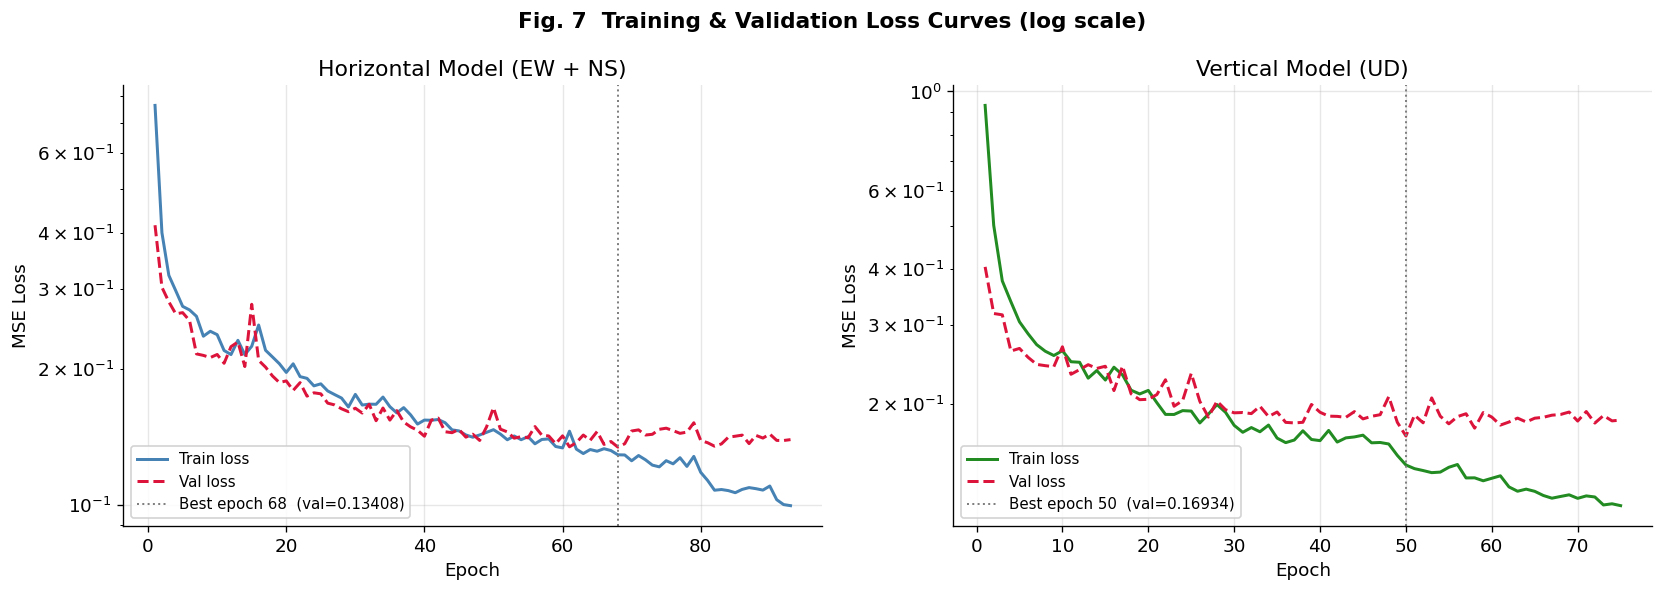

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Fig. 7  Training & Validation Loss Curves (log scale)',
             fontsize=13, fontweight='bold')

for ax, hist, title, col in zip(axes,
    [hist_H, hist_V],
    ['Horizontal Model (EW + NS)', 'Vertical Model (UD)'],
    ['steelblue', 'forestgreen']):

    eps = range(1, len(hist['train']) + 1)
    ax.semilogy(eps, hist['train'], color=col, lw=1.8, label='Train loss')
    ax.semilogy(eps, hist['val'],   color='crimson', ls='--', lw=1.8, label='Val loss')

    best_ep = int(np.argmin(hist['val'])) + 1
    best_v  = min(hist['val'])
    ax.axvline(best_ep, color='grey', ls=':', lw=1.2,
               label=f'Best epoch {best_ep}  (val={best_v:.5f})')

    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.set_title(title)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


## 9. Evaluation — Test Set Performance

### Metrics Definition

| Metric | Formula | Interpretation |
|:---|:---|:---|
| **RMSE** | $\sqrt{\frac{1}{N \cdot F}\sum_i\sum_j(\hat{y}_{ij}-y_{ij})^2}$ | In log₁₀ units; RMSE=0.30 → factor of 2 error |
| **R²** | $1 - SS_{res}/SS_{tot}$ | 1.0 = perfect; ≥ 0.90 = excellent for seismic models |
| **Bias** | $\bar{\hat{y}} - \bar{y}$ | Positive = systematic over-prediction |
| **σ** | std$(\hat{y} - y)$ | Spread around the mean residual |


In [ ]:
@torch.no_grad()
def get_predictions(model, loader, device=DEVICE):
    """Collect predictions and targets from a DataLoader."""
    model.eval()
    preds, targets = [], []
    for xb, yb in loader:
        preds.append(model(xb.to(device)).cpu().numpy())
        targets.append(yb.numpy())
    return np.vstack(preds), np.vstack(targets)


def print_metrics(y_true, y_pred, label):
    flat_t, flat_p = y_true.flatten(), y_pred.flatten()
    rmse  = np.sqrt(mean_squared_error(flat_t, flat_p))
    r2    = r2_score(flat_t, flat_p)
    bias  = float((y_pred - y_true).mean())
    sigma = float((y_pred - y_true).std())
    print(f"  {'─'*45}")
    print(f"  {label}")
    print(f"    RMSE  (log₁₀ units) : {rmse:.4f}")
    print(f"    R²                  : {r2:.4f}")
    print(f"    Bias  (log₁₀ units) : {bias:+.4f}")
    print(f"    σ     (log₁₀ units) : {sigma:.4f}")
    return rmse, r2, bias, sigma


# ── Get standardised predictions and inverse-scale ────────────────────────────
pred_H_sc, true_H_sc = get_predictions(model_H, ld_H['test'])
pred_V_sc, true_V_sc = get_predictions(model_V, ld_V['test'])

pred_H = sc_H['y'].inverse_transform(pred_H_sc)   # log10(FAS) m/s
true_H = sc_H['y'].inverse_transform(true_H_sc)
pred_V = sc_V['y'].inverse_transform(pred_V_sc)
true_V = sc_V['y'].inverse_transform(true_V_sc)

print("Test Set Metrics:")
m_H = print_metrics(true_H, pred_H, 'Horizontal (EW + NS)')
m_V = print_metrics(true_V, pred_V, 'Vertical   (UD)')


Test Set Metrics:
  ─────────────────────────────────────────────
  Horizontal (EW + NS)
    RMSE  (log₁₀ units) : 0.4076
    R²                  : 0.8352
    Bias  (log₁₀ units) : -0.0337
    σ     (log₁₀ units) : 0.4062
  ─────────────────────────────────────────────
  Vertical   (UD)
    RMSE  (log₁₀ units) : 0.3809
    R²                  : 0.8302
    Bias  (log₁₀ units) : -0.0105
    σ     (log₁₀ units) : 0.3808


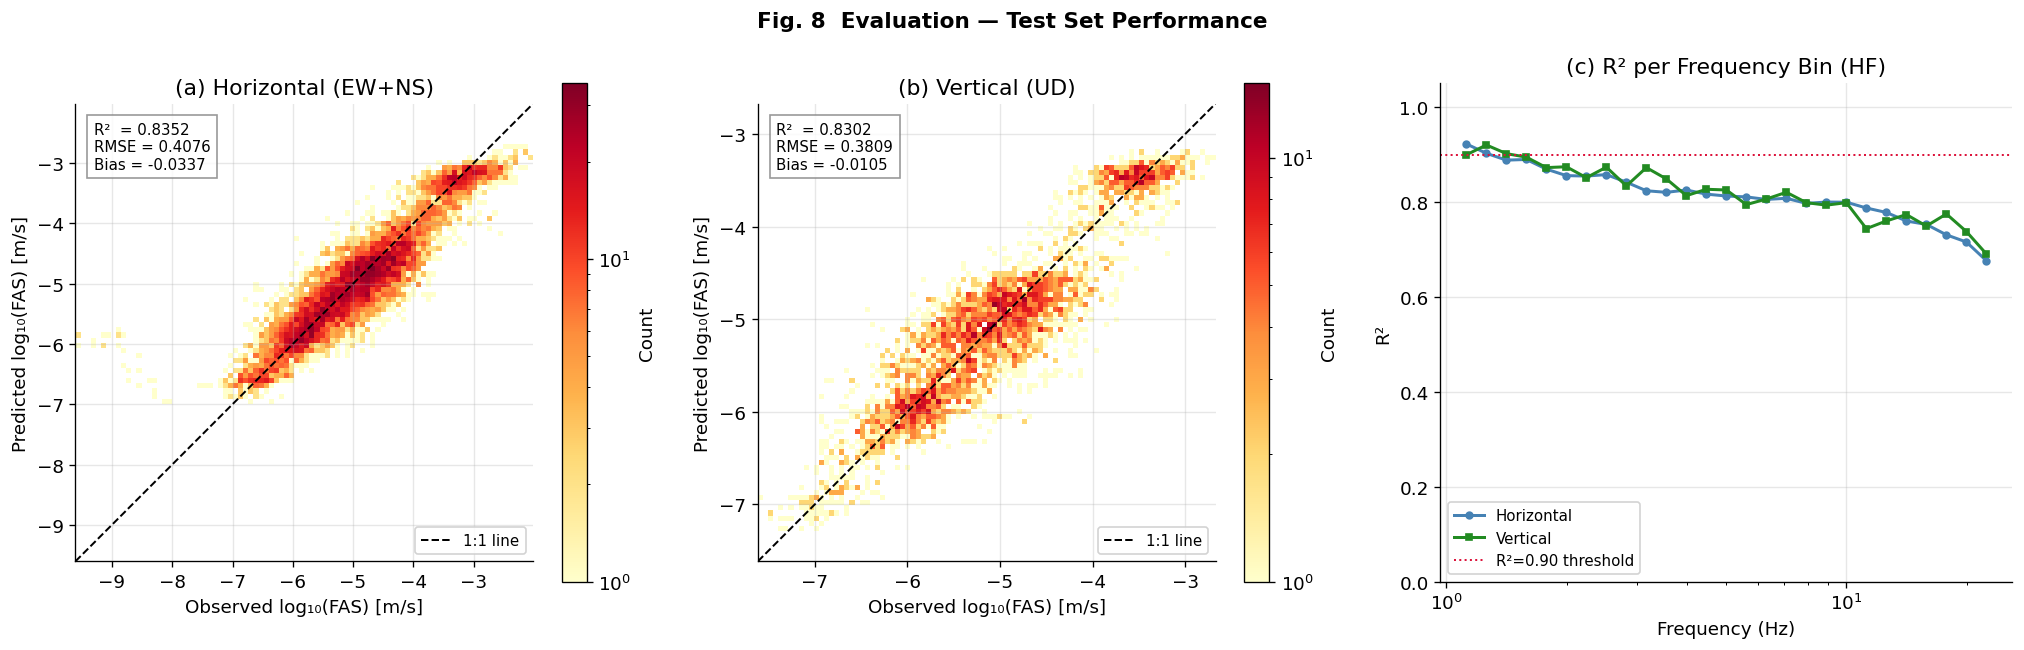

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))
fig.suptitle('Fig. 8  Evaluation — Test Set Performance',
             fontsize=13, fontweight='bold')

# ── (a) Horizontal: Actual vs Predicted 2D histogram ─────────────────────────
ax = axes[0]
mn, mx = min(true_H.min(), pred_H.min()), max(true_H.max(), pred_H.max())
h2 = ax.hist2d(true_H.ravel(), pred_H.ravel(), bins=90,
               range=[[mn,mx],[mn,mx]], cmap='YlOrRd',
               norm=plt.cm.colors.LogNorm())
plt.colorbar(h2[3], ax=ax, label='Count')
ax.plot([mn, mx], [mn, mx], 'k--', lw=1.2, label='1:1 line')
r2   = r2_score(true_H.ravel(), pred_H.ravel())
rmse = np.sqrt(mean_squared_error(true_H.ravel(), pred_H.ravel()))
bias = float((pred_H - true_H).mean())
ax.text(0.04, 0.96, f"R²  = {r2:.4f}\nRMSE = {rmse:.4f}\nBias = {bias:+.4f}",
        transform=ax.transAxes, va='top', fontsize=9,
        bbox=dict(facecolor='white', alpha=0.80, edgecolor='grey'))
ax.set_xlabel('Observed log₁₀(FAS) [m/s]')
ax.set_ylabel('Predicted log₁₀(FAS) [m/s]')
ax.set_title('(a) Horizontal (EW+NS)')
ax.legend(fontsize=9); ax.set_aspect('equal')

# ── (b) Vertical: Actual vs Predicted 2D histogram ───────────────────────────
ax = axes[1]
mn, mx = min(true_V.min(), pred_V.min()), max(true_V.max(), pred_V.max())
h2 = ax.hist2d(true_V.ravel(), pred_V.ravel(), bins=90,
               range=[[mn,mx],[mn,mx]], cmap='YlOrRd',
               norm=plt.cm.colors.LogNorm())
plt.colorbar(h2[3], ax=ax, label='Count')
ax.plot([mn, mx], [mn, mx], 'k--', lw=1.2, label='1:1 line')
r2   = r2_score(true_V.ravel(), pred_V.ravel())
rmse = np.sqrt(mean_squared_error(true_V.ravel(), pred_V.ravel()))
bias = float((pred_V - true_V).mean())
ax.text(0.04, 0.96, f"R²  = {r2:.4f}\nRMSE = {rmse:.4f}\nBias = {bias:+.4f}",
        transform=ax.transAxes, va='top', fontsize=9,
        bbox=dict(facecolor='white', alpha=0.80, edgecolor='grey'))
ax.set_xlabel('Observed log₁₀(FAS) [m/s]')
ax.set_ylabel('Predicted log₁₀(FAS) [m/s]')
ax.set_title('(b) Vertical (UD)')
ax.legend(fontsize=9); ax.set_aspect('equal')

# ── (c) R² per frequency bin ──────────────────────────────────────────────────
ax = axes[2]
r2_H = [r2_score(true_H[:, j], pred_H[:, j]) for j in range(N_OUTPUTS)]
r2_V = [r2_score(true_V[:, j], pred_V[:, j]) for j in range(N_OUTPUTS)]
ax.semilogx(output_freqs, r2_H, 'o-', color='steelblue',
            lw=1.8, ms=4, label='Horizontal')
ax.semilogx(output_freqs, r2_V, 's-', color='forestgreen',
            lw=1.8, ms=4, label='Vertical')
ax.axhline(0.90, color='crimson', ls=':', lw=1.2, label='R²=0.90 threshold')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('R²')
ax.set_title('(c) R² per Frequency Bin (HF)')
ax.legend(fontsize=9); ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()


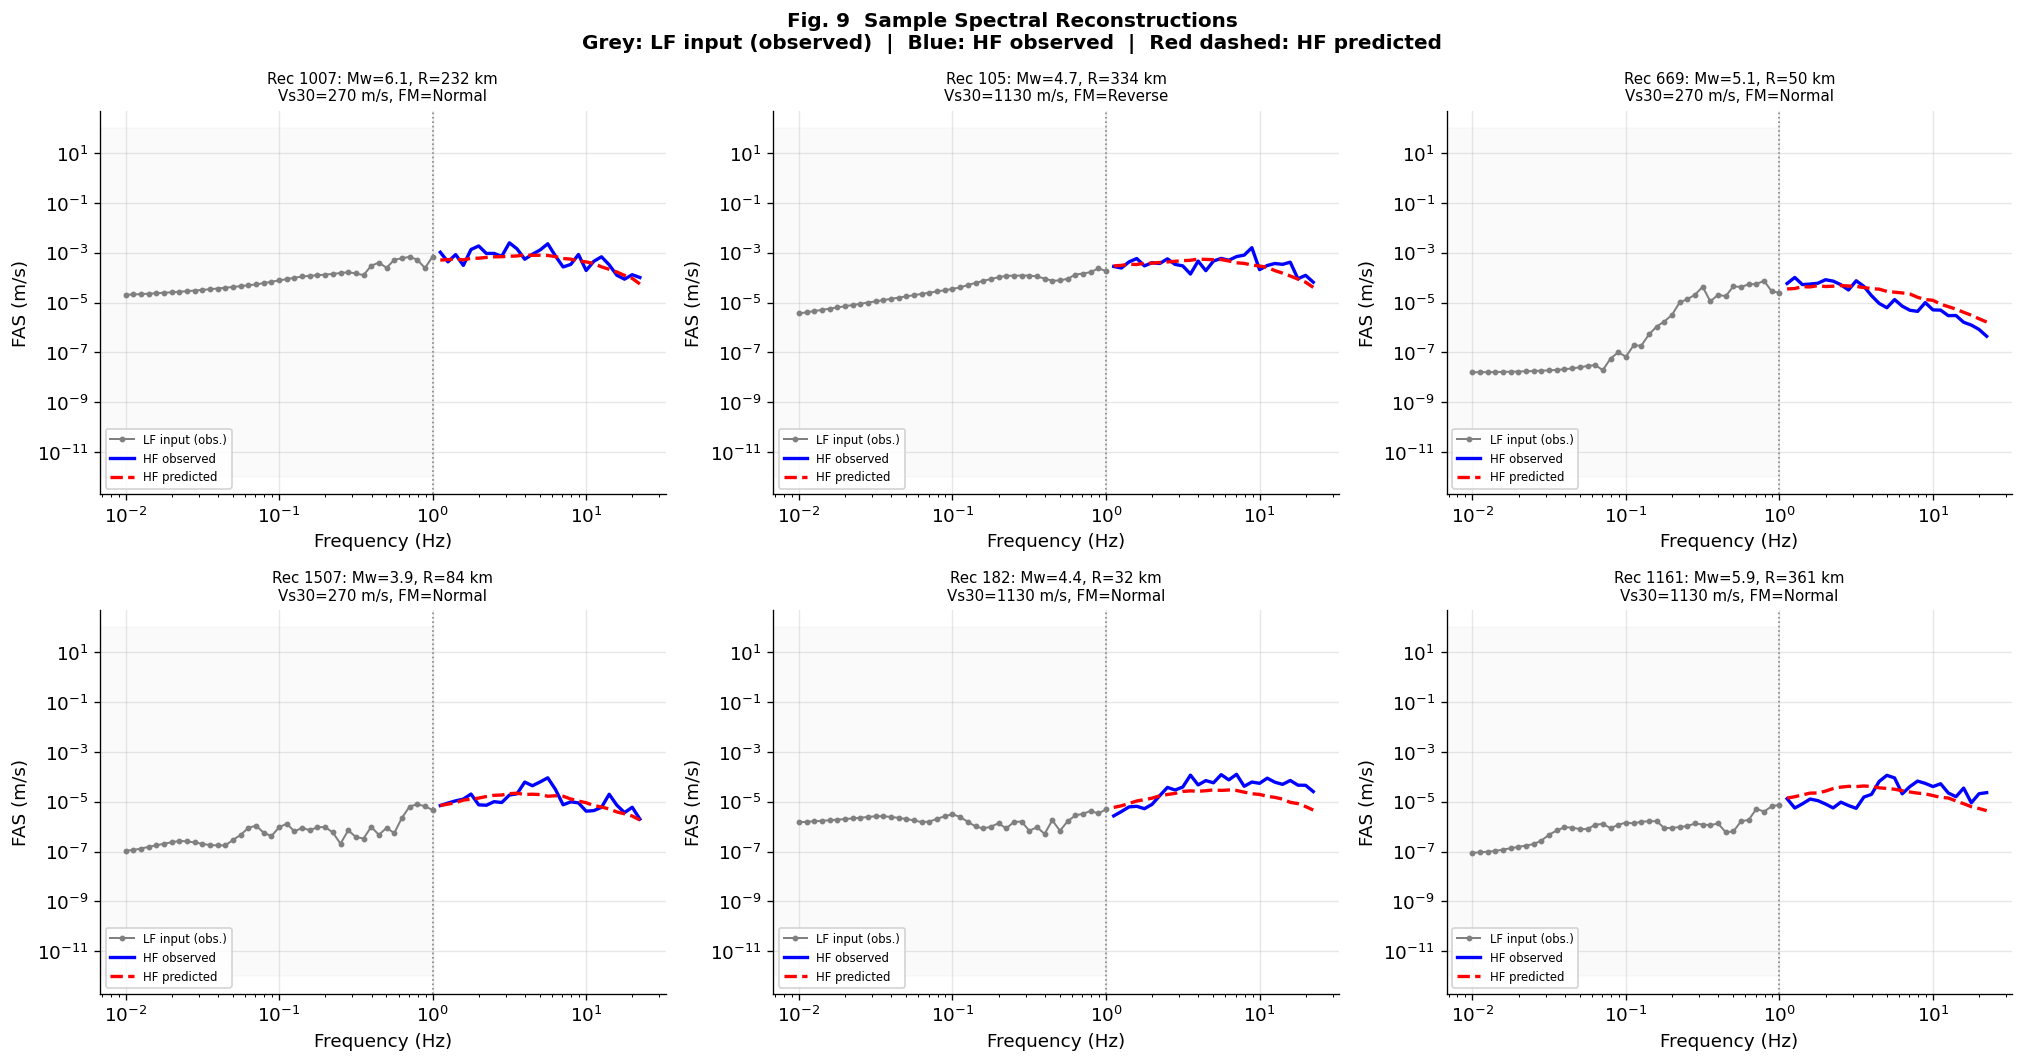

In [ ]:
# ── Sample spectral reconstructions ──────────────────────────────────────────
np.random.seed(42)
show_recs = np.random.choice(len(true_H), 6, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(17, 9))
fig.suptitle('Fig. 9  Sample Spectral Reconstructions\n'
             'Grey: LF input (observed)  |  Blue: HF observed  |  Red dashed: HF predicted',
             fontsize=12, fontweight='bold')

n_ew = len(df_ew)
for plot_i, rec_i in enumerate(show_recs):
    ax = axes[plot_i // 3, plot_i % 3]

    lf_log  = X_H[te_H[rec_i], :, 0]   # raw log10(FAS) from unscaled feature col 0
    hf_obs  = true_H[rec_i]
    hf_pred = pred_H[rec_i]

    # Retrieve metadata
    global_idx = te_H[rec_i]
    src_df  = df_ew if global_idx < n_ew else df_ns
    local_i = global_idx % n_ew
    repi = src_df['Repi'].iloc[local_i]
    vs30 = src_df['Vs30'].iloc[local_i]
    mw   = src_df['Magnitude'].iloc[local_i]
    fm   = fm_map.get(int(src_df['FM'].iloc[local_i]), '?')

    ax.axvline(1.0, color='grey', ls=':', lw=1, zorder=1)
    ax.fill_betweenx([1e-12, 1e2], 0, 1, alpha=0.04, color='grey', zorder=0)
    ax.plot(input_freqs,  10**lf_log,  'o-', color='grey',    ms=2.5, lw=1.2,
            label='LF input (obs.)')
    ax.plot(output_freqs, 10**hf_obs,  'b-', lw=2.0,          label='HF observed')
    ax.plot(output_freqs, 10**hf_pred, 'r--', lw=2.0,          label='HF predicted')
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('Frequency (Hz)'); ax.set_ylabel('FAS (m/s)')
    ax.set_title(f'Rec {global_idx}: Mw={mw:.1f}, R={repi:.0f} km\n'
                 f'Vs30={vs30:.0f} m/s, FM={fm}', fontsize=9)
    ax.legend(fontsize=7, loc='lower left')

plt.tight_layout()
plt.show()


## 10. Detailed Residual Analysis

### Definition

$$\varepsilon_i(f_j) = \log_{10}\hat{\text{FAS}}_i(f_j) - \log_{10}\text{FAS}_i^{\text{obs}}(f_j)$$

Positive residual = model **over-predicts** amplitude; negative = **under-predicts**.

### Six Diagnostic Checks

| Check | What it reveals |
|:---|:---|
| **Histogram** | Overall bias and spread; symmetry around zero |
| **Mean ± σ vs frequency** | Frequency-dependent trends; heteroscedasticity |
| **Mean ± σ vs Repi** | Distance-dependent bias (unmodelled geometric spreading) |
| **Mean ± σ vs Magnitude** | Source-dependent bias (unmodelled stress drop variability) |

A well-calibrated model should show residuals centred near **zero for all diagnostics** with roughly constant spread.


In [ ]:
resid_H = pred_H - true_H   # (N_test, N_OUTPUTS) positive = over-prediction
resid_V = pred_V - true_V

# ── Test-set metadata ─────────────────────────────────────────────────────────
n_ew = len(df_ew)
meta_H_test = pd.DataFrame({
    'Repi':      np.concatenate([df_ew['Repi'].values,      df_ns['Repi'].values])[te_H],
    'Vs30':      np.concatenate([df_ew['Vs30'].values,      df_ns['Vs30'].values])[te_H],
    'Magnitude': np.concatenate([df_ew['Magnitude'].values, df_ns['Magnitude'].values])[te_H],
    'FM':        np.concatenate([df_ew['FM'].values,        df_ns['FM'].values])[te_H],
    'Equid':     np.concatenate([df_ew['Equid'].values,     df_ns['Equid'].values])[te_H],
})
meta_V_test = pd.DataFrame({
    'Repi':      df_ud['Repi'].values[te_V],
    'Vs30':      df_ud['Vs30'].values[te_V],
    'Magnitude': df_ud['Magnitude'].values[te_V],
    'FM':        df_ud['FM'].values[te_V],
    'Equid':     df_ud['Equid'].values[te_V],
})

print(f"Horizontal test residuals shape : {resid_H.shape}")
print(f"Vertical   test residuals shape : {resid_V.shape}")
print(f"H residual overall:  μ={resid_H.mean():.4f}  σ={resid_H.std():.4f}")
print(f"V residual overall:  μ={resid_V.mean():.4f}  σ={resid_V.std():.4f}")


Horizontal test residuals shape : (278, 27)
Vertical   test residuals shape : (140, 27)
H residual overall:  μ=-0.0337  σ=0.4062
V residual overall:  μ=-0.0105  σ=0.3808


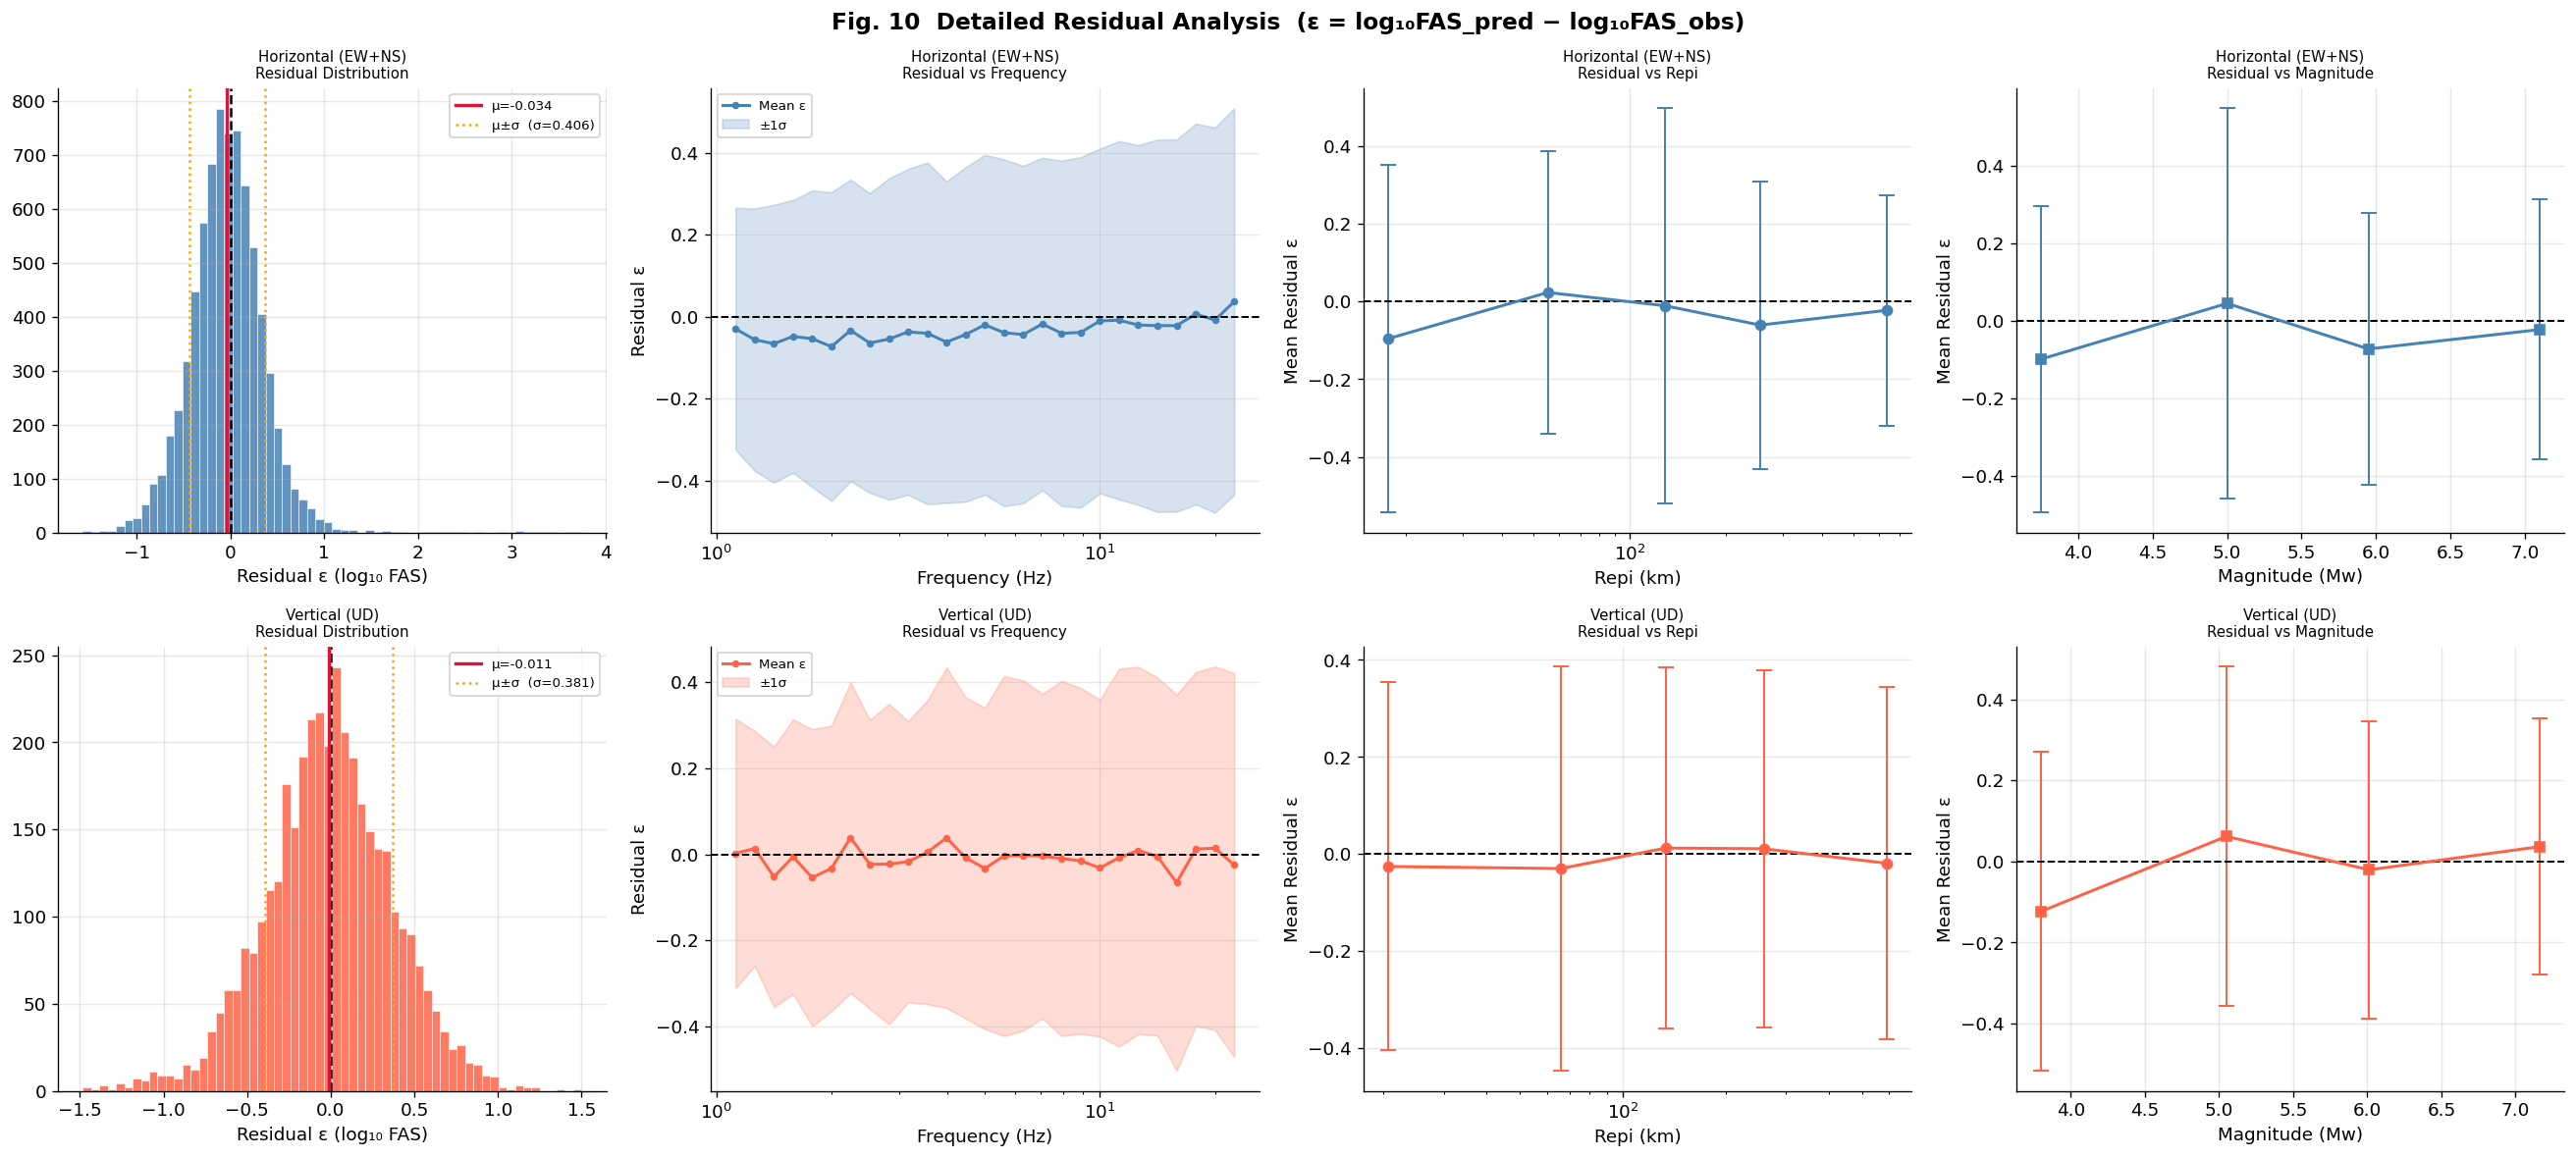

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
fig.suptitle('Fig. 10  Detailed Residual Analysis  (ε = log₁₀FAS_pred − log₁₀FAS_obs)',
             fontsize=14, fontweight='bold')

for row, (resid, meta, title, col) in enumerate([
    (resid_H, meta_H_test, 'Horizontal (EW+NS)', 'steelblue'),
    (resid_V, meta_V_test, 'Vertical (UD)',       'tomato'),
]):
    flat_r = resid.ravel()

    # ── Col 0: Residual histogram ─────────────────────────────────────────────
    ax = axes[row, 0]
    ax.hist(flat_r, bins=60, color=col, edgecolor='white', alpha=0.85, linewidth=0.4)
    ax.axvline(0, color='k', ls='--', lw=1.5)
    ax.axvline(flat_r.mean(), color='crimson', ls='-', lw=2.0,
               label=f'μ={flat_r.mean():.3f}')
    ax.axvline(flat_r.mean() + flat_r.std(), color='orange', ls=':', lw=1.5,
               label=f'μ±σ  (σ={flat_r.std():.3f})')
    ax.axvline(flat_r.mean() - flat_r.std(), color='orange', ls=':', lw=1.5)
    ax.set_xlabel('Residual ε (log₁₀ FAS)')
    ax.set_title(f'{title}\nResidual Distribution', fontsize=9)
    ax.legend(fontsize=8)

    # ── Col 1: Mean ± 1σ vs frequency ────────────────────────────────────────
    ax = axes[row, 1]
    mean_r = resid.mean(axis=0)
    std_r  = resid.std(axis=0)
    ax.semilogx(output_freqs, mean_r, 'o-', color=col, ms=3.5, lw=1.8, label='Mean ε')
    ax.fill_between(output_freqs, mean_r - std_r, mean_r + std_r,
                    color=col, alpha=0.22, label='±1σ')
    ax.axhline(0, color='k', ls='--', lw=1.2)
    ax.set_xlabel('Frequency (Hz)'); ax.set_ylabel('Residual ε')
    ax.set_title(f'{title}\nResidual vs Frequency', fontsize=9)
    ax.legend(fontsize=8)

    # ── Col 2: Residual vs Repi (quintile bins) ───────────────────────────────
    ax = axes[row, 2]
    repi = meta['Repi'].values
    qbins = np.percentile(repi, [0, 20, 40, 60, 80, 100])
    bids  = np.digitize(repi, qbins[1:-1])
    bmeans = [resid[bids == b].mean() for b in range(5)]
    bstds  = [resid[bids == b].std()  for b in range(5)]
    bcents = [(qbins[i]+qbins[i+1])/2 for i in range(5)]
    ax.errorbar(bcents, bmeans, yerr=bstds, fmt='o-', color=col,
                capsize=5, capthick=1.2, lw=1.8, ms=6, elinewidth=1.2)
    ax.axhline(0, color='k', ls='--', lw=1.2)
    ax.set_xscale('log')
    ax.set_xlabel('Repi (km)'); ax.set_ylabel('Mean Residual ε')
    ax.set_title(f'{title}\nResidual vs Repi', fontsize=9)

    # ── Col 3: Residual vs Magnitude (quartile bins) ──────────────────────────
    ax = axes[row, 3]
    mag   = meta['Magnitude'].values
    mbins = np.percentile(mag, [0, 25, 50, 75, 100])
    mids  = np.digitize(mag, mbins[1:-1])
    mmeans = [resid[mids == b].mean() for b in range(4)]
    mstds  = [resid[mids == b].std()  for b in range(4)]
    mcents = [(mbins[i]+mbins[i+1])/2 for i in range(4)]
    ax.errorbar(mcents, mmeans, yerr=mstds, fmt='s-', color=col,
                capsize=5, capthick=1.2, lw=1.8, ms=6, elinewidth=1.2)
    ax.axhline(0, color='k', ls='--', lw=1.2)
    ax.set_xlabel('Magnitude (Mw)'); ax.set_ylabel('Mean Residual ε')
    ax.set_title(f'{title}\nResidual vs Magnitude', fontsize=9)


plt.tight_layout()
plt.show()


## 11. Standard Deviation Decomposition

### 11.1 Theory and Motivation

In empirical ground-motion modelling, the total aleatory variability in log-space residuals is decomposed into physically interpretable components:

$$\sigma_{\text{total}}^2(f) = \tau^2(f) + \phi^2(f)$$

| Component | Symbol | Physical Meaning |
|:---|:---:|:---|
| **Total std dev** | $\sigma_{\text{total}}$ | Overall uncertainty of the LNN prediction |
| **Inter-event std dev** | $\tau$ | Earthquake-to-earthquake variability not explained by Mw alone (stress drop, rupture directivity, radiation pattern) |
| **Intra-event std dev** | $\phi$ | Record-to-record variability within one earthquake (path differences, site microstructure, instrument noise) |





In [ ]:
def sigma_decomp(residuals, equids):
    """
    Decompose residuals (N_test, N_freq) into:
      tau         : (N_freq,) inter-event standard deviation
      phi         : (N_freq,) intra-event standard deviation
      sigma_total : (N_freq,) = sqrt(tau² + phi²)
      event_terms : dict {event_id → (N_freq,) mean inter-event residual}

    Parameters
    ----------
    residuals : (N, N_freq) array — log-unit residuals (pred − obs)
    equids    : (N,) array — event identifiers per record

    Returns
    -------
    tau, phi, sigma_total : each (N_freq,)
    event_terms : dict
    """
    N, n_freq   = residuals.shape
    tau_arr     = np.zeros(n_freq)
    phi_arr     = np.zeros(n_freq)
    event_terms = {}

    events = np.unique(equids)

    for j in range(n_freq):
        r = residuals[:, j]

        # Step 1–2: Inter-event — mean residual per event
        ev_means = {}
        for e in events:
            mask = (equids == e)
            if mask.sum() > 0:
                ev_means[e] = r[mask].mean()

        ev_mean_arr = np.array(list(ev_means.values()))
        tau_arr[j]  = ev_mean_arr.std(ddof=1) if len(ev_mean_arr) > 1 else 0.0

        # Step 3–4: Intra-event — within-event residuals
        demeaned = np.array([
            r[i] - ev_means.get(equids[i], 0.0) for i in range(N)
        ])
        phi_arr[j] = demeaned.std(ddof=1)

    sigma_total = np.sqrt(tau_arr**2 + phi_arr**2)

    # Store event terms for distribution diagnostics
    for ev_id in events:
        mask = (equids == ev_id)
        if mask.sum() > 0:
            event_terms[ev_id] = np.array([
                residuals[mask, j].mean() for j in range(n_freq)
            ])

    return tau_arr, phi_arr, sigma_total, event_terms


# ── Event IDs for test records ────────────────────────────────────────────────
equid_H_test = np.concatenate([df_ew['Equid'].values, df_ns['Equid'].values])[te_H]
equid_V_test = df_ud['Equid'].values[te_V]

tau_H, phi_H, sig_H, evterms_H = sigma_decomp(resid_H, equid_H_test)
tau_V, phi_V, sig_V, evterms_V = sigma_decomp(resid_V, equid_V_test)

print("Sigma Decomposition Summary  (median over HF frequency range):")
print(f"  {'Component':<20}  {'Horizontal':>12}  {'Vertical':>12}")
print(f"  {'─'*46}")
for name, h_arr, v_arr in [
    ('σ_total', sig_H, sig_V),
    ('τ (inter-event)', tau_H, tau_V),
    ('φ (intra-event)', phi_H, phi_V),
    ('τ/φ ratio', tau_H/np.where(phi_H>0,phi_H,1), tau_V/np.where(phi_V>0,phi_V,1)),
]:
    print(f"  {name:<20}  {np.median(h_arr):>12.4f}  {np.median(v_arr):>12.4f}")


Sigma Decomposition Summary  (median over HF frequency range):
  Component               Horizontal      Vertical
  ──────────────────────────────────────────────
  σ_total                     0.4475        0.4395
  τ (inter-event)             0.3445        0.3864
  φ (intra-event)             0.2945        0.2163
  τ/φ ratio                   1.2239        1.7342


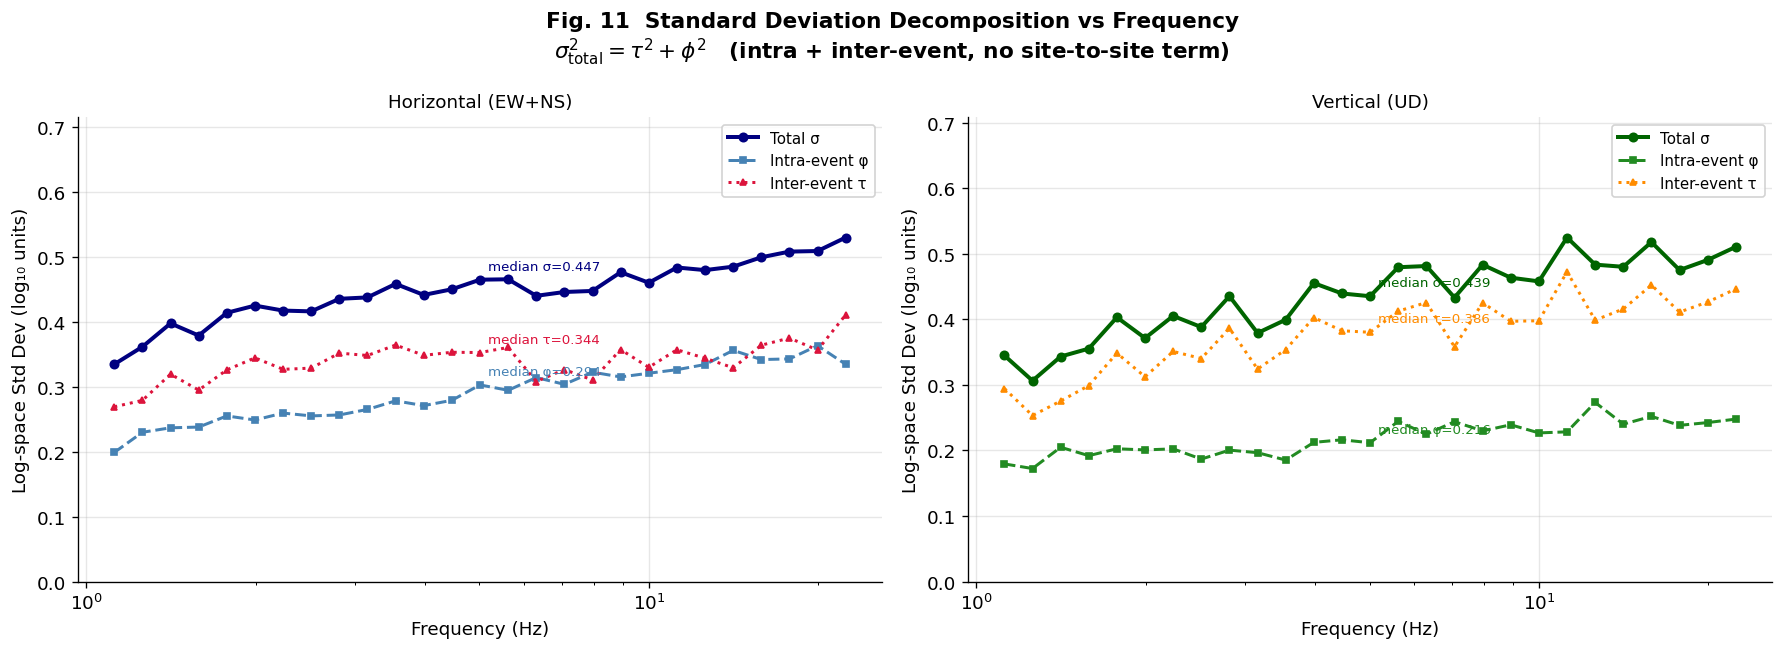

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
fig.suptitle('Fig. 11  Standard Deviation Decomposition vs Frequency\n'
             r'$\sigma_{\rm total}^2 = \tau^2 + \phi^2$   '
             '(intra + inter-event, no site-to-site term)',
             fontsize=13, fontweight='bold')

style = [
    (sig_H, phi_H, tau_H, 'Horizontal (EW+NS)',
     'navy', 'steelblue', 'crimson'),
    (sig_V, phi_V, tau_V, 'Vertical (UD)',
     'darkgreen', 'forestgreen', 'darkorange'),
]

for ax, (sig, phi, tau, title, c_s, c_p, c_t) in zip(axes, style):
    ax.semilogx(output_freqs, sig, 'o-',  color=c_s, lw=2.4, ms=5, label='Total σ')
    ax.semilogx(output_freqs, phi, 's--', color=c_p, lw=1.8, ms=4, label='Intra-event φ')
    ax.semilogx(output_freqs, tau, '^:',  color=c_t, lw=1.8, ms=4, label='Inter-event τ')

    # Annotate medians
    for arr, sym, col in [(sig,'σ',c_s),(phi,'φ',c_p),(tau,'τ',c_t)]:
        mid_idx = len(output_freqs) // 2
        ax.annotate(f'median {sym}={np.median(arr):.3f}',
                    xy=(output_freqs[mid_idx], arr[mid_idx]),
                    xytext=(5, 6), textcoords='offset points',
                    fontsize=8, color=col)

    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Log-space Std Dev (log₁₀ units)')
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9)
    ax.set_ylim(0, max(sig.max(), phi.max()) * 1.35)

plt.tight_layout()
plt.show()


## 12. BA18 GMM Implementation & GMM-Driven Parametric Analysis

### 12.1 Pipeline Overview

```
Metadata (Mw, Repi, Vs30, FM, Depth)
        │
        ▼
  BA18 GMM (Bayless & Abrahamson 2019)
        │  Smooth median EAS → 41 LF bins (0.01–1.0 Hz)
        ▼
  LNN Model (trained: Metadata + LF FAS features)
        │  Predicted HF log₁₀(FAS) at N_OUTPUTS bins (>1 Hz)
        ▼
  Full Predicted Spectrum (LF from GMM  +  HF from LNN)
```

### 12.2 Why GMM for LF Input?

Real recorded LF FAS has high record-to-record scatter. Using the **BA18 GMM median** as LF input provides:
- A smooth, noise-free LF boundary condition for the LNN
- Clean parametric sensitivity: varying one parameter at a time is interpretable
- Consistent comparison across (Mw, Repi, Vs30, FM) scenario combinations



In [ ]:
# ── BA18 frequency grid (239 points: 0.1 – 23.99 Hz) ──────────────────────────
_BA18_FREQ = np.array([
    0.1,0.1023293,0.1047129,0.10715192,0.10964782,0.11220184,0.1148154,0.1174898,
    0.12022643,0.1230269,0.12589254,0.12882494,0.1318257,0.1348963,0.13803841,
    0.14125373,0.144544,0.14791083,0.15135611,0.1548817,0.15848931,0.162181,
    0.1659587,0.1698244,0.1737801,0.177828,0.1819701,0.18620871,0.1905461,
    0.19498443,0.1995262,0.2041738,0.20892961,0.2137962,0.2187762,0.22387212,
    0.2290868,0.2344229,0.2398833,0.2454709,0.2511886,0.25703954,0.2630268,
    0.26915344,0.2754229,0.2818383,0.28840312,0.29512092,0.3019952,0.30902954,
    0.3162278,0.32359364,0.3311311,0.33884412,0.34673681,0.3548134,0.3630781,
    0.37153521,0.3801894,0.38904511,0.39810714,0.4073803,0.4168694,0.42657953,
    0.4365158,0.4466836,0.4570882,0.4677351,0.4786301,0.48977881,0.5011872,
    0.51286131,0.5248075,0.5370318,0.5495409,0.5623413,0.57543992,0.5888436,
    0.6025595,0.61659491,0.6309573,0.6456543,0.6606934,0.676083,0.69183093,
    0.7079458,0.72443592,0.74131023,0.7585776,0.7762471,0.79432821,0.81283044,
    0.8317637,0.8511381,0.8709636,0.8912509,0.9120108,0.93325424,0.9549925,
    0.9772371,1.0,1.023293,1.047129,1.0715192,1.096478,1.1220182,1.1481534,
    1.1748973,1.2022641,1.230269,1.258926,1.28825,1.318257,1.348963,1.3803842,
    1.4125374,1.44544,1.4791082,1.513561,1.5488164,1.584893,1.62181,1.659587,
    1.698244,1.737801,1.7782794,1.819701,1.862087,1.905461,1.9498444,1.9952621,
    2.041738,2.089296,2.137962,2.187761,2.2387211,2.290868,2.344229,2.398833,
    2.454709,2.5118863,2.570396,2.630268,2.691535,2.7542283,2.818383,2.884031,
    2.951209,3.019952,3.090296,3.162278,3.235937,3.311311,3.3884413,3.4673681,
    3.548134,3.63078,3.715352,3.8018932,3.890451,3.981071,4.073803,4.168694,
    4.2657952,4.365158,4.4668354,4.5708813,4.677351,4.7863001,4.897787,5.011872,
    5.128613,5.248074,5.3703184,5.495409,5.623413,5.7543992,5.8884363,6.025596,
    6.1659493,6.309573,6.456542,6.606934,6.7608284,6.9183082,7.0794563,7.24436,
    7.413103,7.585776,7.762471,7.9432821,8.1283044,8.3176364,8.5113792,8.709635,
    8.912507,9.120107,9.332541,9.549923,9.7723722,10.0,10.23293,10.471284,
    10.715192,10.96478,11.220183,11.481534,11.748973,12.022642,12.302684,12.589251,
    12.882492,13.182563,13.489624,13.80384,14.12537,14.454392,14.79108,15.135614,
    15.48817,15.848933,16.218101,16.59587,16.98244,17.37801,17.782793,18.19701,
    18.62087,19.05461,19.498443,19.952621,20.41738,20.89296,21.37962,21.877611,
    22.38721,22.908672,23.442283,23.988321])

_FOUT = np.concatenate([_BA18_FREQ, [
    24.54708,25.11886,25.70395,26.30267,26.91534,27.542291,28.183832,28.84032,
    29.512094,30.19952,30.902954,31.62278,32.359363,33.11311,33.884414,34.673683,
    35.481334,36.3078,37.153514,38.018932,38.90451,39.81071,40.73802,41.68693,
    42.65794,43.65157,44.668342,45.70881,46.7735,47.862991,48.97789,50.11873,
    51.286144,52.480751,53.703182,54.95409,56.23413,57.543991,58.884361,60.255954,
    61.6595,63.09573,64.565414,66.06933,67.608283,69.183082,70.79456,72.443572,
    74.131004,75.857734,77.62469,79.432792,81.28303,83.17635,85.11377,87.096321,
    89.1251,91.2011,93.32544,95.49926,97.723724,100.0]])

print(f"BA18 primary grid : {len(_BA18_FREQ)} points  [{_BA18_FREQ[0]:.3f}–{_BA18_FREQ[-1]:.3f} Hz]")
print(f"Extended 301-pt   : {len(_FOUT)} points ")


BA18 primary grid : 239 points  [0.100–23.988 Hz]
Extended 301-pt   : 301 points 


In [ ]:
def parse_matlab_array(text, varname):
    """Extract a 1-D numeric array from MATLAB source code."""
    pattern = rf'{varname}\s*=\s*\[(.*?)\];'
    match   = re.search(pattern, text, re.DOTALL)
    if not match:
        raise ValueError(f'Variable "{varname}" not found in MATLAB source')
    body = re.sub(r'%.*', '', match.group(1)).replace('...', '')
    nums = re.findall(r'[+-]?(?:\d+\.?\d*|\.\d+)(?:[eE][+-]?\d+)?', body)
    return np.array([float(x) for x in nums])


def load_ba18_coeffs(matlab_path='ba_2019_EAS.m'):
    """Parse coefficient arrays from the BA18 MATLAB source file."""
    with open(matlab_path, 'r') as fh:
        src = fh.read()
    beta_flat = parse_matlab_array(src, 'beta')
    alea_flat = parse_matlab_array(src, 'aleatory')
    f3 = parse_matlab_array(src, 'f3')
    f4 = parse_matlab_array(src, 'f4')
    f5 = parse_matlab_array(src, 'f5')
    try:
        freq_grid = parse_matlab_array(src, 'freq')
    except ValueError:
        freq_grid = _BA18_FREQ
    beta = beta_flat.reshape(18, 239)
    alea = alea_flat.reshape(6, 301)
    assert beta.shape == (18, 239), f"beta shape mismatch: {beta.shape}"
    assert alea.shape == (6, 301),  f"alea shape mismatch: {alea.shape}"
    return beta, alea, f3, f4, f5, freq_grid


try:
    _beta, _alea, _f3, _f4, _f5, _BA18_FREQ = load_ba18_coeffs('ba_2019_EAS.m')
    _BA18_LOADED = True
    print("✅ BA18 coefficients loaded successfully from ba_2019_EAS.m")
    print(f"   beta: {_beta.shape}   alea: {_alea.shape}   "
          f"f3/f4/f5: {_f3.shape}")
except FileNotFoundError:
    _BA18_LOADED = False
    print("⚠️  ba_2019_EAS.m not found in working directory.")
    print("   Place the MATLAB file alongside this notebook and re-run.")
    print("   Sections 12.4+ (GMM parametric plots) will be skipped.")


✅ BA18 coefficients loaded successfully from ba_2019_EAS.m
   beta: (18, 239)   alea: (6, 301)   f3/f4/f5: (301,)


In [ ]:
def _ba18_eas_array(mag, Rrup, Vs, Ztor, FNorm, Z1=-1):
    """
    Compute BA18 median EAS spectrum (Bayless & Abrahamson 2019).

    Parameters
    ----------
    mag   : float — moment magnitude Mw
    Rrup  : float — rupture distance (km); approximated as sqrt(Repi²+Depth²)
    Vs    : float — Vs30 (m/s)
    Ztor  : float — depth to top of rupture (km); use focal depth
    FNorm : int   — 1 if Normal fault (FM==2), else 0
    Z1    : float — depth to Vs=1 km/s horizon (km); -1 = estimate from Vs30

    Returns
    -------
    EAS_array : (301,) in g·s (acceleration FAS amplitude)
    sigma     : (301,) total aleatory std dev (ln units)
    fout      : (301,) Hz
    """
    b1,b2,b3q,bn,bM,b4,b5,b6,bhm,b7,b8,b9,b10,b11a,b11b,b11c,b11d,b1a = _beta
    b4a = -0.5; Vsref = 1000.; Mbreak = 6.0

    # Z1 reference (depth to 1 km/s horizon from Vs30)
    Z1ref = (1./1000) * np.exp(
        -7.67/4 * np.log((Vs**4 + 610**4) / (1360**4 + 610**4)))
    if Z1 == -1:
        Z1 = Z1ref

    # Select b11 based on Vs30 category
    if   Vs <= 200: b11 = b11a
    elif Vs <= 300: b11 = b11b
    elif Vs <= 500: b11 = b11c
    else:           b11 = b11d

    # ── Linear source + path + site spectrum ─────────────────────────────────
    lnFAS = (
        b1
        + b2*(mag - Mbreak)
        + b3q*np.log(1 + np.exp(bn*(bM - mag)))
        + b4*np.log(Rrup + b5*np.cosh(b6*np.maximum(mag - bhm, 0)))
        + (b4a - b4)*np.log(np.sqrt(Rrup**2 + 50.**2))
        + b7*Rrup
        + b8*np.log(np.minimum(Vs, 1000)/Vsref)
        + b9*np.minimum(Ztor, 20.)
        + b10*FNorm
        + b11*np.log((np.minimum(Z1, 2) + 0.01) / (Z1ref + 0.01))
    )
    FAS_spectrum = np.exp(lnFAS)   # (239,) g·s

    # ── High-frequency kappa extrapolation (239→301 points) ──────────────────
    maxfreq = 23.988321
    kappa   = np.exp(-0.4*np.log(Vs/760.) - 3.5)
    imax    = np.searchsorted(_BA18_FREQ, maxfreq)
    fextrap = _FOUT[imax:]
    D       = np.exp(-np.pi*kappa*(fextrap - maxfreq))
    EAS_lin = np.concatenate([FAS_spectrum[:imax], FAS_spectrum[imax-1]*D])

    # ── Nonlinear site amplification ──────────────────────────────────────────
    i5 = np.argmin(np.abs(_BA18_FREQ - 5.011872))
    lnFAS_rock5 = (
        b1[i5] + b2[i5]*(mag - Mbreak)
        + b3q[i5]*np.log(1 + np.exp(bn[i5]*(bM[i5] - mag)))
        + b4[i5]*np.log(Rrup + b5[i5]*np.cosh(b6[i5]*np.maximum(mag-bhm[i5], 0)))
        + (b4a - b4[i5])*np.log(np.sqrt(Rrup**2 + 50.**2))
        + b7[i5]*Rrup + b9[i5]*np.minimum(Ztor, 20.) + b10[i5]*FNorm
    )
    IR   = np.exp(1.238 + 0.846*lnFAS_rock5)
    Vref = 760.
    f2   = _f4*(np.exp(_f5*(np.minimum(Vs, Vref) - 360)) -
                np.exp(_f5*(Vref - 360)))
    fNL0 = f2*np.log((IR + _f3)/_f3)
    ym   = fNL0.min(); yi = fNL0.argmin()
    fNL  = uniform_filter1d(
        np.concatenate([fNL0[:yi], np.full(301-yi, ym)]), size=20)
    EAS_array = EAS_lin * np.exp(fNL)

    # ── Aleatory sigma ────────────────────────────────────────────────────────
    s1,s2,s3,s4,s5,s6 = _alea
    if   mag < 4: tau_s, phi_s2s_s, phi_ss_s = s1, s3, s5
    elif mag > 6: tau_s, phi_s2s_s, phi_ss_s = s2, s4, s6
    else:
        t = (mag - 4)/2
        tau_s    = s1 + (s2-s1)*t
        phi_s2s_s = s3 + (s4-s3)*t
        phi_ss_s  = s5 + (s6-s5)*t
    c1a   = np.concatenate([b1a, np.zeros(62)])
    sigma = np.sqrt(tau_s**2 + phi_s2s_s**2 + phi_ss_s**2 + c1a**2)

    return EAS_array, sigma, _FOUT


def gmm_lf_fas(mag, Repi, Vs30, Depth, fm_code, freqs_lf=None, Z1=-1):
    """
    Compute BA18 median EAS at LF input bins and convert to log₁₀(FAS [m/s]).

    - Below 0.1 Hz: flat extrapolation from EAS(0.1 Hz)
    - Unit: EAS [g·s] × 9.81 m/s²/g = FAS [m/s]
    """
    if freqs_lf is None:
        freqs_lf = input_freqs
    Rrup  = np.sqrt(Repi**2 + Depth**2)
    FNorm = 1 if fm_code == 2 else 0
    eas_arr, _, fout = _ba18_eas_array(mag, Rrup, Vs30, Depth, FNorm, Z1)

    log_f_out = np.log10(fout)
    log_eas   = np.log10(np.clip(eas_arr, 1e-50, None))

    log_fas_lf = np.array([
        np.interp(np.log10(np.clip(f, fout[0], fout[-1])), log_f_out, log_eas)
        for f in freqs_lf
    ])
    log_fas_lf += np.log10(9.81)   # g·s → m/s
    return log_fas_lf


if _BA18_LOADED:
    lf_chk = gmm_lf_fas(6.0, 50., 760., 10., 4)
    print("BA18 sanity check (Mw=6, Repi=50 km, Vs30=760 m/s):")
    print(f"  LF range: [{lf_chk.min():.3f}, {lf_chk.max():.3f}] log₁₀(m/s)")
    print(f"  FAS at 1 Hz: {lf_chk[-1]:.4f} log₁₀(m/s) = {10**lf_chk[-1]:.2e} m/s")


BA18 sanity check (Mw=6, Repi=50 km, Vs30=760 m/s):
  LF range: [-2.385, -1.301] log₁₀(m/s)
  FAS at 1 Hz: -1.3009 log₁₀(m/s) = 5.00e-02 m/s


In [ ]:
def predict_spectrum(mag, Repi, Vs30, Depth, fm_code, model, scaler_X, stitch=True):
    """
    Full GMM → LNN prediction pipeline.

    Steps
    -----
    1. BA18 GMM → log₁₀(FAS [m/s]) at 41 LF bins
    2. Build (1, 41, 8) meta_lf feature tensor
    3. Scale features with training scaler
    4. LNN → raw HF log₁₀(FAS) at N_OUTPUTS bins
    5. Inverse-scale targets
    6. [Optional] Junction stitch: shift HF by (GMM@1Hz − LNN@1Hz)

    Returns
    -------
    log_lf        : (41,)       GMM LF prediction in log₁₀(FAS m/s)
    hf_out        : (N_OUTPUTS,) LNN HF prediction (stitched if stitch=True)
    stitch_offset : float        log₁₀ offset applied (0.0 if stitch=False)
    """
    fm = fm_code
    meta = np.array([
        np.log10(Repi  + 1e-9),
        np.log10(Depth + 1e-9),
        float(fm == 1), float(fm == 3), float((fm == 2) or (fm == 4)),
        1.0 / (Repi + 1e-9),
        mag,
    ], dtype=np.float32)   # (7,)

    log_lf   = gmm_lf_fas(mag, Repi, Vs30, Depth, fm_code).astype(np.float32)
    T        = len(input_freqs)
    meta_seq = np.tile(meta[np.newaxis, :], (T, 1))   # (T, 7)
    X        = np.concatenate([log_lf[:, np.newaxis], meta_seq], axis=1)[np.newaxis]  # (1,T,8)

    X_sc = scaler_X['X'].transform(X.reshape(1, -1)).reshape(1, T, N_FEATURES)
    X_t  = torch.tensor(X_sc, dtype=torch.float32).to(DEVICE)
    model.eval()
    with torch.no_grad():
        pred_sc = model(X_t).cpu().numpy()
    hf_raw = scaler_X['y'].inverse_transform(pred_sc)[0]   # (N_OUTPUTS,)

    if stitch:
        stitch_offset = float(log_lf[-1] - hf_raw[0])
        hf_out = hf_raw + stitch_offset
    else:
        stitch_offset = 0.0
        hf_out = hf_raw

    return log_lf, hf_out, stitch_offset


if _BA18_LOADED:
    lf_t, hf_t, off_t = predict_spectrum(6.0, 50., 760., 10., 4, model_H, sc_H)
    print("Pipeline test (Mw=6, Repi=50 km, Vs30=760 m/s, FM=4):")
    print(f"  LF range : [{lf_t.min():.3f}, {lf_t.max():.3f}]")
    print(f"  HF range : [{hf_t.min():.3f}, {hf_t.max():.3f}]")
    print(f"  Stitch offset     : {off_t:+.4f} log₁₀")
    print(f"  GMM @1 Hz         : {lf_t[-1]:.4f}")
    print(f"  LNN @1 Hz         : {hf_t[0]:.4f}")
    print(f"  Junction gap      : {abs(lf_t[-1]-hf_t[0]):.2e}  (should be ≈0)")


Pipeline test (Mw=6, Repi=50 km, Vs30=760 m/s, FM=4):
  LF range : [-2.385, -1.301]
  HF range : [-3.515, -1.265]
  Stitch offset     : +1.4272 log₁₀
  GMM @1 Hz         : -1.3009
  LNN @1 Hz         : -1.3009
  Junction gap      : 0.00e+00  (should be ≈0)


In [ ]:
if _BA18_LOADED:
    BASE = dict(Depth=10., fm_code=4)

    scenarios = {
        'repi': dict(
            title='(a) Varying Epicentral Distance\nVs30=760 m/s, Mw=6.0',
            cases=[
                {**BASE,'mag':6.,'Vs30':760.,'Repi':10., 'label':'10 km', 'color':'#d62728','ls':'-'},
                {**BASE,'mag':6.,'Vs30':760.,'Repi':20., 'label':'20 km', 'color':'#ff7f0e','ls':'-'},
                {**BASE,'mag':6.,'Vs30':760.,'Repi':50., 'label':'50 km', 'color':'#bcbd22','ls':'-'},
                {**BASE,'mag':6.,'Vs30':760.,'Repi':100.,'label':'100 km','color':'#1f77b4','ls':'--'},
                {**BASE,'mag':6.,'Vs30':760.,'Repi':200.,'label':'200 km','color':'#17becf','ls':'--'},
            ]),
        'vs30': dict(
            title='(b) Varying Site Condition (Vs30)\nRepi=50 km, Mw=6.0',
            cases=[
                {**BASE,'mag':6.,'Repi':50.,'Vs30':270., 'label':'270 m/s (soft)',  'color':'#d62728','ls':'-'},
                {**BASE,'mag':6.,'Repi':50.,'Vs30':560., 'label':'560 m/s (stiff)', 'color':'#ff7f00','ls':'--'},
                {**BASE,'mag':6.,'Repi':50.,'Vs30':1130.,'label':'1130 m/s (rock)', 'color':'#2ca02c','ls':'--'},
            ]),
        'mag': dict(
            title='(c) Varying Magnitude\nRepi=50 km, Vs30=760 m/s',
            cases=[
                {**BASE,'Repi':50.,'Vs30':760.,'mag':4.5,'label':'Mw 4.5','color':'#bcbd22','ls':'-'},
                {**BASE,'Repi':50.,'Vs30':760.,'mag':5.0,'label':'Mw 5.0','color':'#ff7f0e','ls':'-'},
                {**BASE,'Repi':50.,'Vs30':760.,'mag':6.0,'label':'Mw 6.0','color':'#d62728','ls':'-'},
                {**BASE,'Repi':50.,'Vs30':760.,'mag':7.0,'label':'Mw 7.0','color':'#7f7f7f','ls':'--'},
            ]),
        'fm': dict(
            title='(d) Varying Fault Mechanism\nRepi=50 km, Vs30=760 m/s, Mw=6.0',
            cases=[
                {**BASE,'mag':6.,'Repi':50.,'Vs30':760.,'fm_code':2,'label':'Normal',     'color':'#377eb8','ls':'--'},
                {**BASE,'mag':6.,'Repi':50.,'Vs30':760.,'fm_code':3,'label':'Reverse',    'color':'#4daf4a','ls':'-.'},
            ]),
    }

    # ── Compute all predictions ───────────────────────────────────────────────
    results_gmm = {}
    for key, scen in scenarios.items():
        results_gmm[key] = []
        for case in scen['cases']:
            c = {k: v for k, v in case.items() if k not in ('label','color','ls')}
            lf, hf, off = predict_spectrum(**c, model=model_H, scaler_X=sc_H, stitch=True)
            results_gmm[key].append({
                'lf':lf,'hf':hf,'stitch_offset':off,
                'label':case['label'],'color':case['color'],'ls':case['ls']
            })
        offsets = [f"{r['stitch_offset']:+.3f}" for r in results_gmm[key]]
        # print(f"  {key}: {len(results_gmm[key])} cases  |  stitch offsets: {offsets}")
    print("\n✅ All GMM → LNN predictions complete.")
else:
    print("Skipping prediction computation — ba_2019_EAS.m not loaded.")



✅ All GMM → LNN predictions complete.


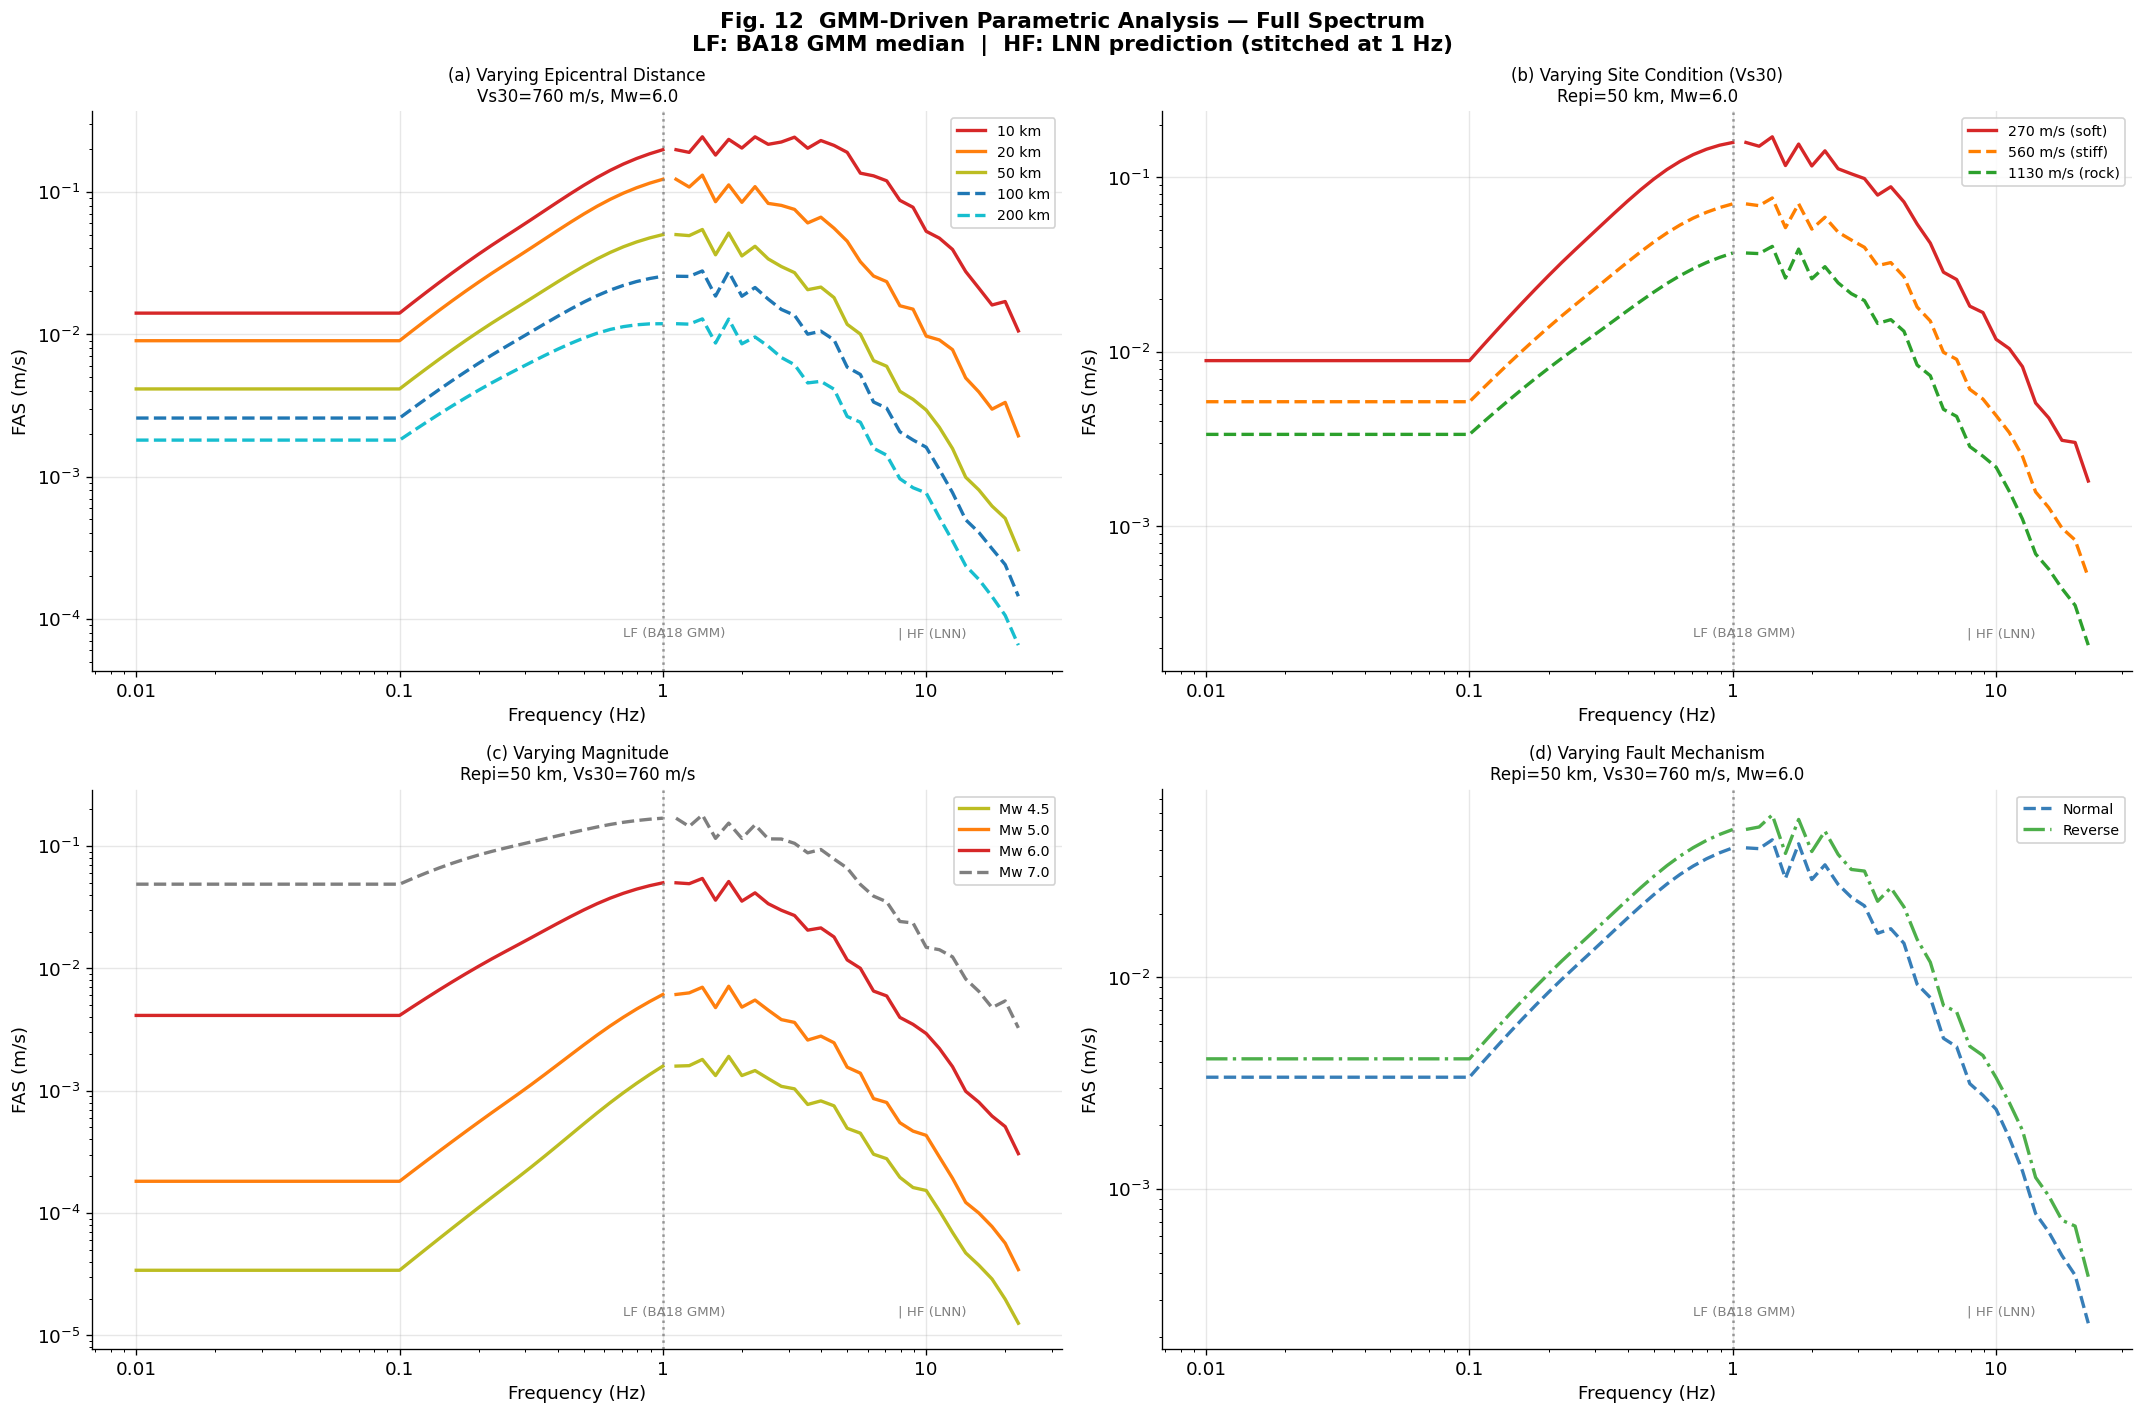

In [ ]:
if _BA18_LOADED:
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    axes = axes.ravel()
    fig.suptitle('Fig. 12  GMM-Driven Parametric Analysis — Full Spectrum\n'
                 'LF: BA18 GMM median  |  HF: LNN prediction (stitched at 1 Hz)',
                 fontsize=13, fontweight='bold')

    for ax, (key, scen) in zip(axes, scenarios.items()):
        for r in results_gmm[key]:
            ax.loglog(input_freqs,  10**r['lf'], color=r['color'],
                      lw=2.0, ls=r['ls'], label=r['label'])
            ax.loglog(output_freqs, 10**r['hf'], color=r['color'],
                      lw=2.0, ls=r['ls'])
        ax.axvline(1.0, color='gray', ls=':', lw=1.5, alpha=0.8)
        ylim = ax.get_ylim()
        ax.text(0.6, 0.06, 'LF (BA18 GMM)', transform=ax.transAxes,
                color='gray', fontsize=8, ha='center')
        ax.text(0.83, 0.06, '| HF (LNN)', transform=ax.transAxes,
                color='gray', fontsize=8, ha='left')
        ax.set_xlabel('Frequency (Hz)')
        ax.set_ylabel('FAS (m/s)')
        ax.set_title(scen['title'], fontsize=10)
        ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'{v:g}'))
        ax.legend(fontsize=8.5, loc='upper right')

    plt.tight_layout()
    plt.show()
else:
    print("Skipping parametric plots.")


## 13. Feature Importance Analysis

In [ ]:
# ── (A) Weight-based importance ───────────────────────────────────────────────
first_cell = model_H.encoder.cells[0]
W          = first_cell.input_map.weight.detach().cpu().numpy()   # (H, D+H)
W_input    = W[:, :N_FEATURES]   # (H, 8) — weights for input features only

FEAT_NAMES = [
    'log₁₀(FAS)', 'log₁₀(Repi)', 'log₁₀(Depth)',
    'FM_SS', 'FM_Rev', 'FM_Nor', '1/Repi', 'Magnitude'
]

# Mean |W| across hidden neurons per feature
mean_abs_w = np.abs(W_input).mean(axis=0)   # (8,)
rel_weights = 100 * mean_abs_w / mean_abs_w.sum()

print("Weight-based feature importance (Horizontal Model, Layer 1):")
for name, imp in sorted(zip(FEAT_NAMES, rel_weights), key=lambda x: -x[1]):
    bar = '█' * int(imp / 2)
    print(f"  {name:<18} {imp:6.2f}%  {bar}")


Weight-based feature importance (Horizontal Model, Layer 1):
  log₁₀(FAS)          18.68%  █████████
  log₁₀(Repi)         13.91%  ██████
  Magnitude           13.81%  ██████
  log₁₀(Depth)        12.89%  ██████
  FM_Rev              10.49%  █████
  1/Repi              10.37%  █████
  FM_Nor              10.01%  █████
  FM_SS                9.84%  ████


In [ ]:
# ── (B) Global permutation importance ─────────────────────────────────────────
def batch_mse(X_arr, y_arr, model, scaler_X, scaler_y):
    """Compute MSE on raw (unscaled) X, y arrays."""
    N    = len(X_arr)
    X_2d = X_arr.reshape(N, -1)
    X_sc = scaler_X.transform(X_2d).reshape(N, N_STEPS, N_FEATURES)
    y_sc = scaler_y.transform(y_arr)
    ds   = SeismicFASDataset(X_sc, y_sc)
    dl   = DataLoader(ds, batch_size=64, shuffle=False)
    crit = nn.MSELoss()
    tot  = 0.0
    with torch.no_grad():
        for xb, yb in dl:
            tot += crit(model(xb.to(DEVICE)), yb.to(DEVICE)).item() * len(xb)
    return tot / N


baseline_mse = batch_mse(X_H_test_raw, y_H_test_raw, model_H,
                          sc_H['X'], sc_H['y'])
print(f"Baseline test MSE (Horizontal): {baseline_mse:.6f}")

N_REPEATS = 5
perm_importance = {}
rng = np.random.default_rng(0)

print(f"\nComputing permutation importance ({N_REPEATS} repeats per feature)...")
for feat_idx, feat_name in enumerate(FEAT_NAMES):
    deltas = []
    for rep in range(N_REPEATS):
        X_perm = X_H_test_raw.copy()
        pi = rng.permutation(len(X_perm))
        X_perm[:, :, feat_idx] = X_perm[pi, :, feat_idx]
        mse_p = batch_mse(X_perm, y_H_test_raw, model_H, sc_H['X'], sc_H['y'])
        deltas.append(mse_p - baseline_mse)
    delta_mean = float(np.mean(deltas))
    perm_importance[feat_name] = delta_mean
    bar = '█' * max(0, int(delta_mean / baseline_mse * 20))
    print(f"  {feat_name:<18} ΔMSE = {delta_mean:.6f}  {bar}")

print("\n✅ Permutation importance complete.")


Baseline test MSE (Horizontal): 0.182952

Computing permutation importance (5 repeats per feature)...
  log₁₀(FAS)         ΔMSE = 1.007249  ██████████████████████████████████████████████████████████████████████████████████████████████████████████████
  log₁₀(Repi)        ΔMSE = 0.188270  ████████████████████
  log₁₀(Depth)       ΔMSE = 0.166175  ██████████████████
  FM_SS              ΔMSE = 0.005325  
  FM_Rev             ΔMSE = 0.011697  █
  FM_Nor             ΔMSE = 0.004466  
  1/Repi             ΔMSE = 0.008010  
  Magnitude          ΔMSE = 0.064504  ███████

✅ Permutation importance complete.


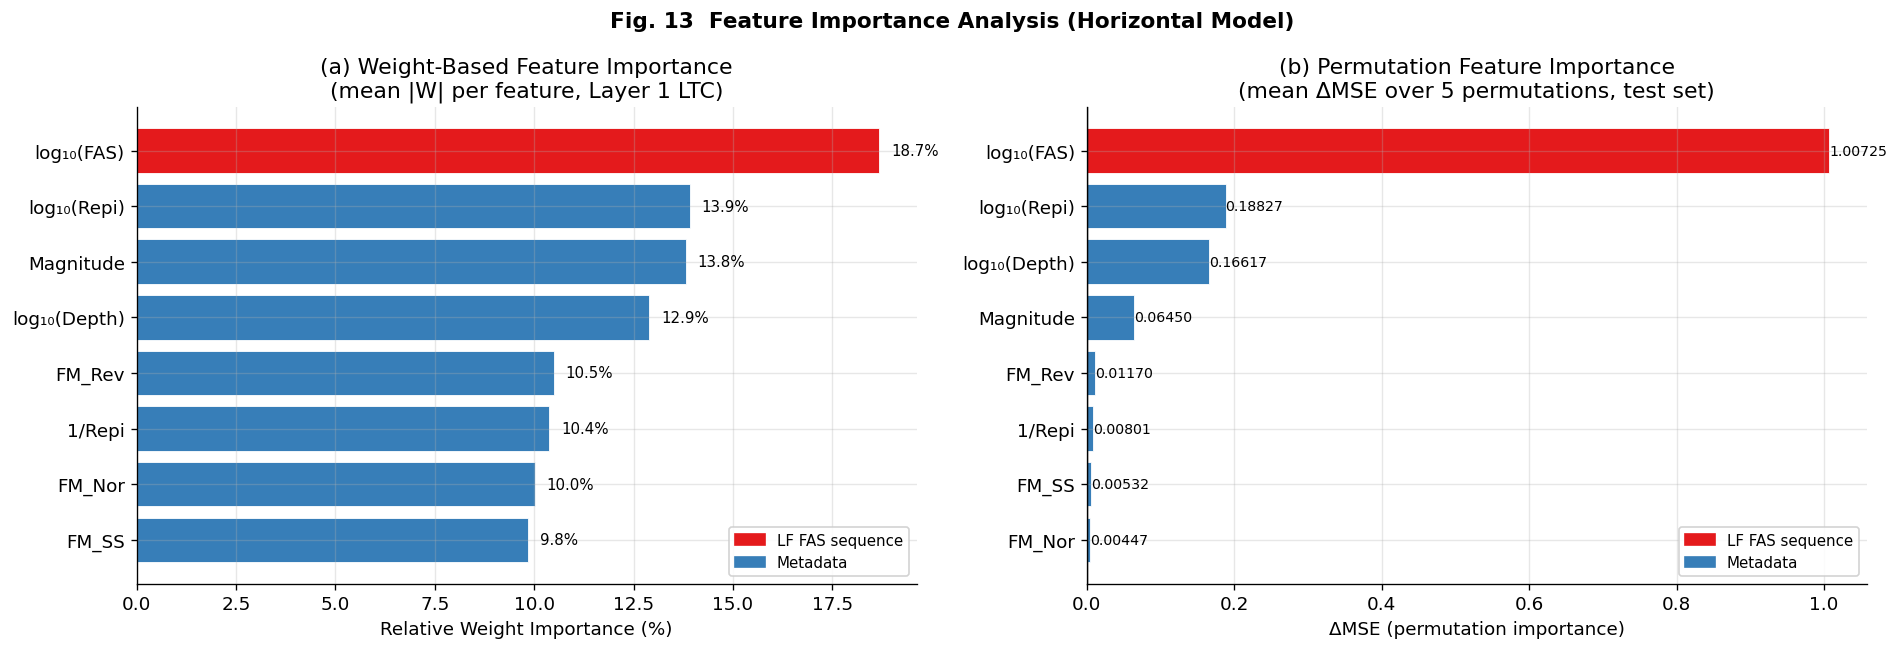

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
fig.suptitle('Fig. 13  Feature Importance Analysis (Horizontal Model)',
             fontsize=13, fontweight='bold')

# ── (a) Weight importance bar chart ───────────────────────────────────────────
ax = axes[0]
feat_colors = ['#e41a1c' if i == 0 else '#377eb8' for i in range(N_FEATURES)]
sorted_feat = sorted(zip(FEAT_NAMES, rel_weights), key=lambda x: x[1])
names_s, weights_s = zip(*sorted_feat)
colors_s = ['#e41a1c' if n == 'log₁₀(FAS)' else '#377eb8' for n in names_s]

bars = ax.barh(names_s, weights_s, color=colors_s, edgecolor='white', linewidth=0.5)
for bar, v in zip(bars, weights_s):
    ax.text(v + 0.3, bar.get_y()+bar.get_height()/2,
            f'{v:.1f}%', va='center', fontsize=9)
ax.set_xlabel('Relative Weight Importance (%)')
ax.set_title('(a) Weight-Based Feature Importance\n(mean |W| per feature, Layer 1 LTC)')
handles = [mpatches.Patch(color='#e41a1c', label='LF FAS sequence'),
           mpatches.Patch(color='#377eb8', label='Metadata')]
ax.legend(handles=handles, fontsize=9, loc='lower right')

# ── (b) Permutation importance bar chart ──────────────────────────────────────
ax = axes[1]
sorted_perm = sorted(perm_importance.items(), key=lambda x: x[1])
pnames, pvals = zip(*sorted_perm)
pcolors = ['#e41a1c' if n == 'log₁₀(FAS)' else '#377eb8' for n in pnames]

bars = ax.barh(pnames, pvals, color=pcolors, edgecolor='white', linewidth=0.5)
ax.axvline(0, color='k', lw=0.8)
for bar, v in zip(bars, pvals):
    ax.text(v + 1e-5, bar.get_y()+bar.get_height()/2,
            f'{v:.5f}', va='center', fontsize=8.5)
ax.set_xlabel('ΔMSE (permutation importance)')
ax.set_title('(b) Permutation Feature Importance\n(mean ΔMSE over 5 permutations, test set)')
ax.legend(handles=handles, fontsize=9, loc='lower right')

plt.tight_layout()
plt.show()


## 14. Model Saving & Final Summary

In [ ]:
# ── Save trained models ───────────────────────────────────────────────────────
torch.save(model_H.state_dict(), 'lnn_horizontal_final.pth')
torch.save(model_V.state_dict(), 'lnn_vertical_final.pth')

with open('scalers_horizontal.pkl', 'wb') as f: pickle.dump(sc_H, f)
with open('scalers_vertical.pkl', 'wb') as f:   pickle.dump(sc_V, f)

print("Saved model weights   : lnn_horizontal_final.pth, lnn_vertical_final.pth")
print("Saved scalers         : scalers_horizontal.pkl, scalers_vertical.pkl")

# ── Save predictions CSV ──────────────────────────────────────────────────────
def save_preds_csv(y_true, y_pred, output_freqs, fname):
    obs  = pd.DataFrame(y_true, columns=[f'obs_{f:.4f}Hz'  for f in output_freqs])
    pred = pd.DataFrame(y_pred, columns=[f'pred_{f:.4f}Hz' for f in output_freqs])
    pd.concat([obs, pred], axis=1).to_csv(fname, index=False)
    print(f"Saved predictions CSV : {fname}  ({len(obs)} test records)")

save_preds_csv(true_H, pred_H, output_freqs, 'predictions_horizontal.csv')
save_preds_csv(true_V, pred_V, output_freqs, 'predictions_vertical.csv')

# ── Final summary table ───────────────────────────────────────────────────────
summary = pd.DataFrame({
    'Model':          ['Horizontal (EW+NS)', 'Vertical (UD)'],
    'Train N':        [sz_H['train'],  sz_V['train']],
    'Val N':          [sz_H['val'],    sz_V['val']],
    'Test N':         [sz_H['test'],   sz_V['test']],
    'LF inputs (T)':  [N_STEPS]*2,
    'HF outputs':     [N_OUTPUTS]*2,
    'Features/step':  [N_FEATURES]*2,
    'Params':         [sum(p.numel() for p in model_H.parameters() if p.requires_grad),
                       sum(p.numel() for p in model_V.parameters() if p.requires_grad)],
    'Test RMSE':      [round(m_H[0], 4), round(m_V[0], 4)],
    'Test R²':        [round(m_H[1], 4), round(m_V[1], 4)],
    'Bias':           [round(m_H[2], 4), round(m_V[2], 4)],
    'σ_total (med.)': [round(float(np.median(sig_H)), 4),
                       round(float(np.median(sig_V)), 4)],
    'τ (med.)':       [round(float(np.median(tau_H)), 4),
                       round(float(np.median(tau_V)), 4)],
    'φ (med.)':       [round(float(np.median(phi_H)), 4),
                       round(float(np.median(phi_V)), 4)],
})

print()
print('='*190)
print('  FINAL SUMMARY — LNN FAS Extrapolation Model')
print('='*190)
print(summary.to_string(index=False))
print('='*190)


Saved model weights   : lnn_horizontal_final.pth, lnn_vertical_final.pth
Saved scalers         : scalers_horizontal.pkl, scalers_vertical.pkl
Saved predictions CSV : predictions_horizontal.csv  (278 test records)
Saved predictions CSV : predictions_vertical.csv  (140 test records)

  FINAL SUMMARY — LNN FAS Extrapolation Model
             Model  Train N  Val N  Test N  LF inputs (T)  HF outputs  Features/step  Params  Test RMSE  Test R²    Bias  σ_total (med.)  τ (med.)  φ (med.)
Horizontal (EW+NS)     1295    277     278             41          27              8  120347     0.4076   0.8352 -0.0337          0.4475    0.3445    0.2945
     Vertical (UD)      647    138     140             41          27              8  120347     0.3809   0.8302 -0.0105          0.4395    0.3864    0.2163
